# Forward Motors: Stage 3 EDA
**DSBA 6165 | Mam Salan Njie and Will Moore**

The question behind this project: MMR is the wholesale price guide dealers rely on. It is accurate on average but can miss badly on an individual car, and we want to predict where it will miss before the bidding starts. That makes `sellingprice` the target, `mmr` an input, and the gap between the two the thing most worth exploring.

This notebook covers the two datasets behind our proposal:

| | Auction prices (Part A) | Damage images (Part B) |
|---|---|---|
| Source | Vehicle Sales Data, Kaggle v1 (Afridi, 2024) | CarDD (Wang, Li & Wu, 2023) |
| Samples | 558,837 transactions; 548,202 after cleaning | 4,000 images; 8,740 damage instances |
| Target | `sellingprice`, continuous (regression) | 6 damage classes + box + mask per instance |
| Split | Whole sale days: 384,673 train / 77,205 val / 86,324 test | Official: 2,816 train / 810 val / 374 test |
| Benchmark | Recorded MMR: \$1,083 MAE on the test split | Published CarDD results |

The CSV is verified against SHA-256 `32ba3ce5…f556` before loading. The two datasets are analyzed separately: no photo is linked to a sale price. MMR publication timing and the meaning of `condition` codes are not documented in the source and are treated as limitations.

## Part A. Auction-price EDA

### How to run
Open in Google Colab and choose **Runtime → Run all**. Both datasets download automatically from Kaggle when they are not on the runner's Google Drive: the auction CSV (about 85 MB) and CarDD (about 3 GB, a few minutes). Each is checked against the release we analyzed before use. The notebook trains no models.

## 1. Data source and loading
Vehicle Sales Data by Syed Anwar Afridi (Kaggle, version 1) records historical wholesale auction transactions. One vehicle may appear in several auction records. The file is checked against its documented SHA-256 before loading, so every number below is tied to one exact version of the data.

In [1]:
import hashlib
import importlib.util
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.patches import Polygon, Rectangle
from matplotlib.ticker import StrMethodFormatter
from PIL import Image
from scipy.stats import chi2_contingency

SEED = 42
IN_COLAB = importlib.util.find_spec("google.colab") is not None

# Our copy lives on Google Drive. If it is not there, the loader downloads the
# public Kaggle dataset (version 1) instead, and checks the same hash either way.
CSV_PATH = Path("/content/drive/MyDrive/forward-motors/car_prices.csv")
KAGGLE_DATASET = "syedanwarafridi/vehicle-sales-data/versions/1"
CSV_SHA256 = "32ba3ce51664e6a12c0c927ed193b41e3c4743fdf18bc0317389892aed27f556"

# CarDD is not on Kaggle; it is released by its authors on request
# (https://cardd-ustc.github.io/). Our copy is a shared Drive folder that only the
# owning Google account can see. Checked in order; the first complete copy wins.
CARDD_CANDIDATES = [
    Path(
        "/content/CarDD_release/CarDD_COCO"
    ),  # staged to local Colab disk earlier in this session
    Path(
        "/content/drive/MyDrive/CarDD_release/CarDD_COCO"
    ),  # Drive shortcut (owner account)
]
CARDD_OWNER_ACCOUNT = "jsmashmusic@gmail.com"
# Public Kaggle copy of the same release, used when our Drive copy is not visible.
CARDD_KAGGLE_DATASET = "issamjebnouni/cardd"

# In Colab, mount Drive so our copies of both datasets are found. Without CarDD on
# your Drive, Part A still runs (the CSV comes from Kaggle) and Part B is skipped loudly.
MOUNT_GOOGLE_DRIVE = IN_COLAB
HASH_CARDD_PIXELS = False
EXPORT_SPLITS = False

### Display settings

In [2]:
# One palette keeps partition identities consistent across every chart.
SPLIT_COLORS = {
    "train": "#35618F",
    "validation": "#8066A6",
    "test": "#B87925",
}
BLUE = "#35618F"
TEAL = "#387D7A"
RUST = "#AD5D49"

pd.set_option("display.max_columns", 20)
pd.set_option("display.max_rows", 30)
pd.set_option("display.precision", 3)

sns.set_theme(style="whitegrid", context="notebook", palette=[BLUE, TEAL, RUST])
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.titleweight": "semibold",
        "axes.titlepad": 14,
        "axes.labelpad": 8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "grid.color": "#E5E8EB",
        "grid.linewidth": 0.6,
        "legend.frameon": False,
        "savefig.bbox": "tight",
    }
)


def format_dollar_axis(axis, which="y"):
    """Show tick labels as $12,000 instead of 12000."""
    target = axis.yaxis if which == "y" else axis.xaxis
    target.set_major_formatter(StrMethodFormatter("${x:,.0f}"))

In [3]:
def find_cardd_root(candidates):
    """Return the first folder that holds the CarDD training annotations, or None."""
    for root in candidates:
        if (root / "annotations" / "instances_train2017.json").is_file():
            return root
    return None


# Mount Drive before looking for CarDD; checking first always reports it missing.
if MOUNT_GOOGLE_DRIVE:
    from google.colab import drive

    if not Path("/content/drive/MyDrive").is_dir():
        drive.mount("/content/drive")

CARDD_ROOT = find_cardd_root(CARDD_CANDIDATES)
RUN_CARDD_EDA = CARDD_ROOT is not None

print(f"Auction CSV on Drive: {CSV_PATH.is_file()} (if False, it downloads from Kaggle)")
print(f"CarDD found at:       {CARDD_ROOT}")
if not RUN_CARDD_EDA:
    checked = "\n".join(f"  {root}" for root in CARDD_CANDIDATES)
    print(
        f"\nCarDD was not found in:\n{checked}\n"
        "Part B will download the public Kaggle copy instead (about 3 GB).\n"
    )

Mounted at /content/drive


In [4]:
def file_sha256(path):
    """Hash a file in small chunks without loading it all into memory."""
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def locate_auction_csv(drive_path, kaggle_dataset):
    """Use our Drive copy if it exists; otherwise download the public Kaggle version."""
    if drive_path.is_file():
        return drive_path

    import kagglehub  # preinstalled in Colab; elsewhere: pip install kagglehub

    download_dir = Path(kagglehub.dataset_download(kaggle_dataset))
    return download_dir / "car_prices.csv"


def load_auction_data(path, expected_hash):
    """Read the documented source version and leave its values untouched."""
    if not path.is_file():
        raise FileNotFoundError(f"car_prices.csv not found at {path}")
    actual_hash = file_sha256(path)
    if actual_hash != expected_hash:
        raise ValueError(
            f"{path} has SHA-256 {actual_hash}, expected {expected_hash}. "
            "This is not the Kaggle v1 file the project documents."
        )
    return pd.read_csv(path)


csv_path = locate_auction_csv(CSV_PATH, KAGGLE_DATASET)
cars = load_auction_data(csv_path, CSV_SHA256)
print(f"Verified CSV: {len(cars):,} auction records, {cars.shape[1]} columns")

# VINs are used for overlap checks, but do not need to appear in a preview.
display(cars.drop(columns=["vin"], errors="ignore").head())

Verified CSV: 558,837 auction records, 16 columns


,year,make,model,trim,body,transmission,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [5]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


### Column meanings

| Column | Meaning |
|---|---|
| `year` | Model year of the vehicle |
| `make`, `model`, `trim`, `body` | What the vehicle is |
| `transmission` | Recorded transmission label; includes missing and anomalous values |
| `vin` | Vehicle identification number, physical-vehicle identifier; repeat transactions are possible |
| `state` | Recorded state code; geographic meaning unverified |
| `condition` | Recorded condition code; scale and availability timing require verification |
| `odometer` | Mileage at sale |
| `color`, `interior` | Exterior and interior color |
| `seller` | Recorded seller label; organization type unverified |
| `mmr` | Recorded MMR benchmark; base/adjusted status and availability timing unverified |
| `sellingprice` | What the vehicle actually sold for, our target |
| `saledate` | Date and time of the sale |

### Field roles and audit table
The data dictionary describes semantic meaning; pandas dtypes only describe storage. The following table joins roles, observed types, uniqueness, and missingness. Identifiers, dates, target-derived residuals, and targets are not ordinary model features. In charts, “auction records (n)” counts rows of the file, not distinct physical vehicles.

In [6]:
# Keep field meaning separate from its storage type.
field_roles = {column: "candidate predictor" for column in cars.columns}
field_roles.update(
    vin="vehicle identifier; exclude from model features",
    saledate="time/split field",
    sellingprice="regression target",
    mmr="recorded benchmark / timing-unverified sensitivity input",
)


field_audit = pd.DataFrame(
    {
        "field": cars.columns,
        "role": [field_roles[column] for column in cars.columns],
        "dtype": [str(cars[column].dtype) for column in cars.columns],
        "unique_nonmissing": [cars[column].nunique() for column in cars.columns],
        "missing_percent": [100 * cars[column].isna().mean() for column in cars.columns],
    }
)
display(field_audit)

numeric_data = cars.select_dtypes(include="number")
display(numeric_data.describe().T.assign(skewness=numeric_data.skew()))

,field,role,dtype,unique_nonmissing,missing_percent
0,year,candidate predictor,int64,34,0.000e+00
1,make,candidate predictor,object,96,1.843e+00
2,model,candidate predictor,object,973,1.861e+00
3,trim,candidate predictor,object,1963,1.906e+00
4,body,candidate predictor,object,87,2.361e+00
5,transmission,candidate predictor,object,4,1.169e+01
6,vin,vehicle identifier; exclude from model features,object,550297,7.158e-04
7,state,candidate predictor,object,64,0.000e+00
8,condition,candidate predictor,float64,41,2.115e+00
9,odometer,candidate predictor,float64,172278,1.682e-02


,count,mean,std,min,25%,50%,75%,max,skewness
year,558837.0,2010.039,3.967,1982.0,2007.0,2012.0,2013.0,2015.0,-1.183
condition,547017.0,30.672,13.403,1.0,23.0,35.0,42.0,49.0,-0.833
odometer,558743.0,68320.018,53398.543,1.0,28371.0,52254.0,99109.0,999999.0,1.843
mmr,558799.0,13769.377,9679.967,25.0,7100.0,12250.0,18300.0,182000.0,1.998
sellingprice,558825.0,13611.359,9749.502,1.0,6900.0,12100.0,18200.0,230000.0,1.953


## 2. Transmission accounts for the largest missing-data share
The saved raw-data audit reports 65,352 missing transmission values (11.694%). The following table is ordered by missing count; its denominator is all 558,837 transaction rows.

,missing,percent
transmission,65352,11.694
body,13195,2.361
condition,11820,2.115
trim,10651,1.906
model,10399,1.861
make,10301,1.843
color,749,0.134
interior,749,0.134
odometer,94,0.017
mmr,38,0.007


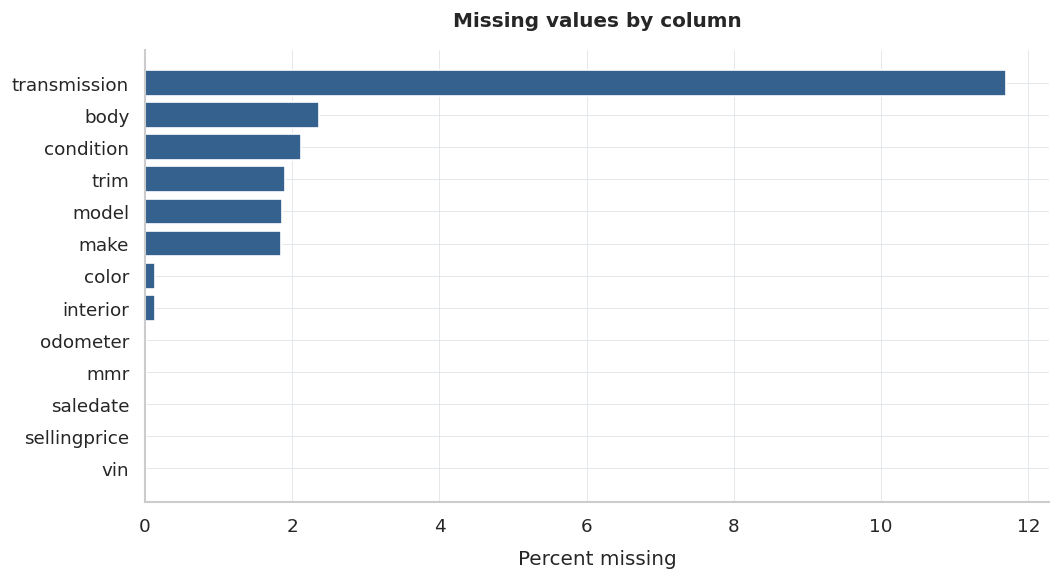

In [7]:
missing = pd.DataFrame(
    {"missing": cars.isna().sum(), "percent": (cars.isna().mean() * 100).round(3)}
).sort_values("missing", ascending=False)

display(missing)

plt.figure(figsize=(9, 5))
subset = missing[missing["missing"] > 0]
plt.barh(subset.index[::-1], subset["percent"][::-1], color="#35618F")
plt.xlabel("Percent missing")
plt.title("Missing values by column")
plt.tight_layout()
plt.show()

`transmission` is missing on 11.7% of records. That is too many to drop, and transmission is not central to price for most of these vehicles, so the blanks become their own category, "unknown", instead of costing us one record in nine.

The description fields (`make`, `model`, `trim`, `body`) are each missing on about 2% of records, and the next cell shows they are usually missing together. A record with no make and no model tells us almost nothing about the car, so cleaning drops it. `sellingprice`, `mmr` and `saledate` are missing on only a handful of records; without the target or the benchmark a record cannot be used or scored.

In [8]:
# Are the description fields missing on the same rows?
desc_cols = ["make", "model", "trim", "body"]
missing_any = cars[desc_cols].isna().any(axis=1).sum()
missing_all = cars[desc_cols].isna().all(axis=1).sum()

print(f"Rows missing at least one description field: {missing_any:,}")
print(f"Rows missing all four description fields:    {missing_all:,}")
print(
    f"So {missing_all / max(missing_any, 1):.1%} of the affected rows are missing all four at once."
)

Rows missing at least one description field: 13,293
Rows missing all four description fields:    10,301
So 77.5% of the affected rows are missing all four at once.


### Duplicates
Two different questions: is any record an exact copy of another, and does the same vehicle (VIN) appear more than once? A repeated VIN is usually a real resale, not an error.

In [ ]:
exact_duplicate_records = cars.duplicated().sum()
repeated_vin_and_date = (
    cars.dropna(subset=["vin"]).duplicated(subset=["vin", "saledate"]).sum()
)
vin_counts = cars["vin"].value_counts()

print(f"Exact duplicate records:                     {exact_duplicate_records:,}")
print(f"Same VIN on the same sale date (repeats):    {repeated_vin_and_date:,}")
print(f"Distinct VINs:                               {len(vin_counts):,}")
print(f"VINs that appear in more than one record:    {(vin_counts > 1).sum():,}")

## 3. Auction prices have a long right tail
`sellingprice` is the recorded dollar outcome, a continuous regression target with no classes. The raw-data median is \$12,100; the 99th percentile is \$44,900 and the maximum \$230,000. Compare the original and log-scale distributions before deciding how to model the tail.

In [9]:
price = cars["sellingprice"].dropna()

print(price.describe().round(0).to_string())
print()
for q in [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999]:
    print(f"  {q:>6.1%} percentile: ${price.quantile(q):>10,.0f}")
print(f"\nSkewness: {price.skew():.2f}")

count    558825.0
mean      13611.0
std        9750.0
min           1.0
25%        6900.0
50%       12100.0
75%       18200.0
max      230000.0

    1.0% percentile: $       500
    5.0% percentile: $     1,500
   25.0% percentile: $     6,900
   50.0% percentile: $    12,100
   75.0% percentile: $    18,200
   95.0% percentile: $    30,600
   99.0% percentile: $    44,900
   99.9% percentile: $    78,000

Skewness: 1.95


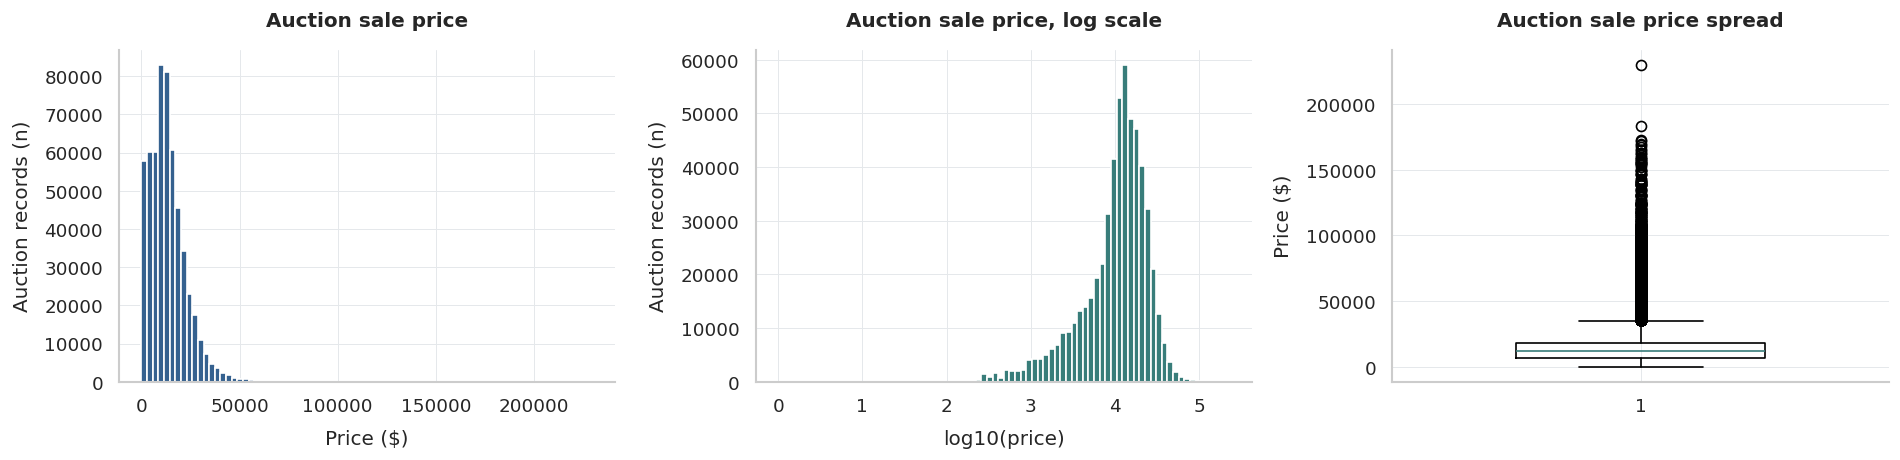

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(price, bins=80, color="#35618F", edgecolor="white")
axes[0].set_title("Auction sale price")
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("Auction records (n)")

axes[1].hist(np.log10(price[price > 0]), bins=80, color="#387D7A", edgecolor="white")
axes[1].set_ylabel("Auction records (n)")
axes[1].set_title("Auction sale price, log scale")
axes[1].set_xlabel("log10(price)")

axes[2].boxplot(price, vert=True, widths=0.5)
axes[2].set_title("Auction sale price spread")
axes[2].set_ylabel("Price ($)")

plt.tight_layout()
plt.show()

The distribution is right-skewed: the median is \$12,100, but the 99th percentile is \$44,900 and the maximum \$230,000.

Two consequences for modeling. Average dollar error is dominated by the expensive end, so we report percentage error alongside it and break error out by price band. And a model trained on raw dollars will spend much of its capacity on the few expensive cars, so predicting log price is a reasonable alternative to test in Stage 4.

## 4. Numeric features

In [11]:
num_cols = ["year", "condition", "odometer", "mmr", "sellingprice"]
cars[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
year,558837.0,2010.04,3.97,1982.0,2007.0,2012.0,2013.0,2015.0
condition,547017.0,30.67,13.40,1.0,23.0,35.0,42.0,49.0
odometer,558743.0,68320.02,53398.54,1.0,28371.0,52254.0,99109.0,999999.0
mmr,558799.0,13769.38,9679.97,25.0,7100.0,12250.0,18300.0,182000.0
sellingprice,558825.0,13611.36,9749.50,1.0,6900.0,12100.0,18200.0,230000.0


Before reading the charts: `condition` is not the 1-to-5 grade dealers usually talk about. It runs from 1 to 49 with a mean near 31. The source does not document the scale, so we treat it as an ordered code. `odometer` has a maximum of 999,999 miles, which looks like a placeholder rather than a real reading; cleaning drops anything above 500,000 miles.

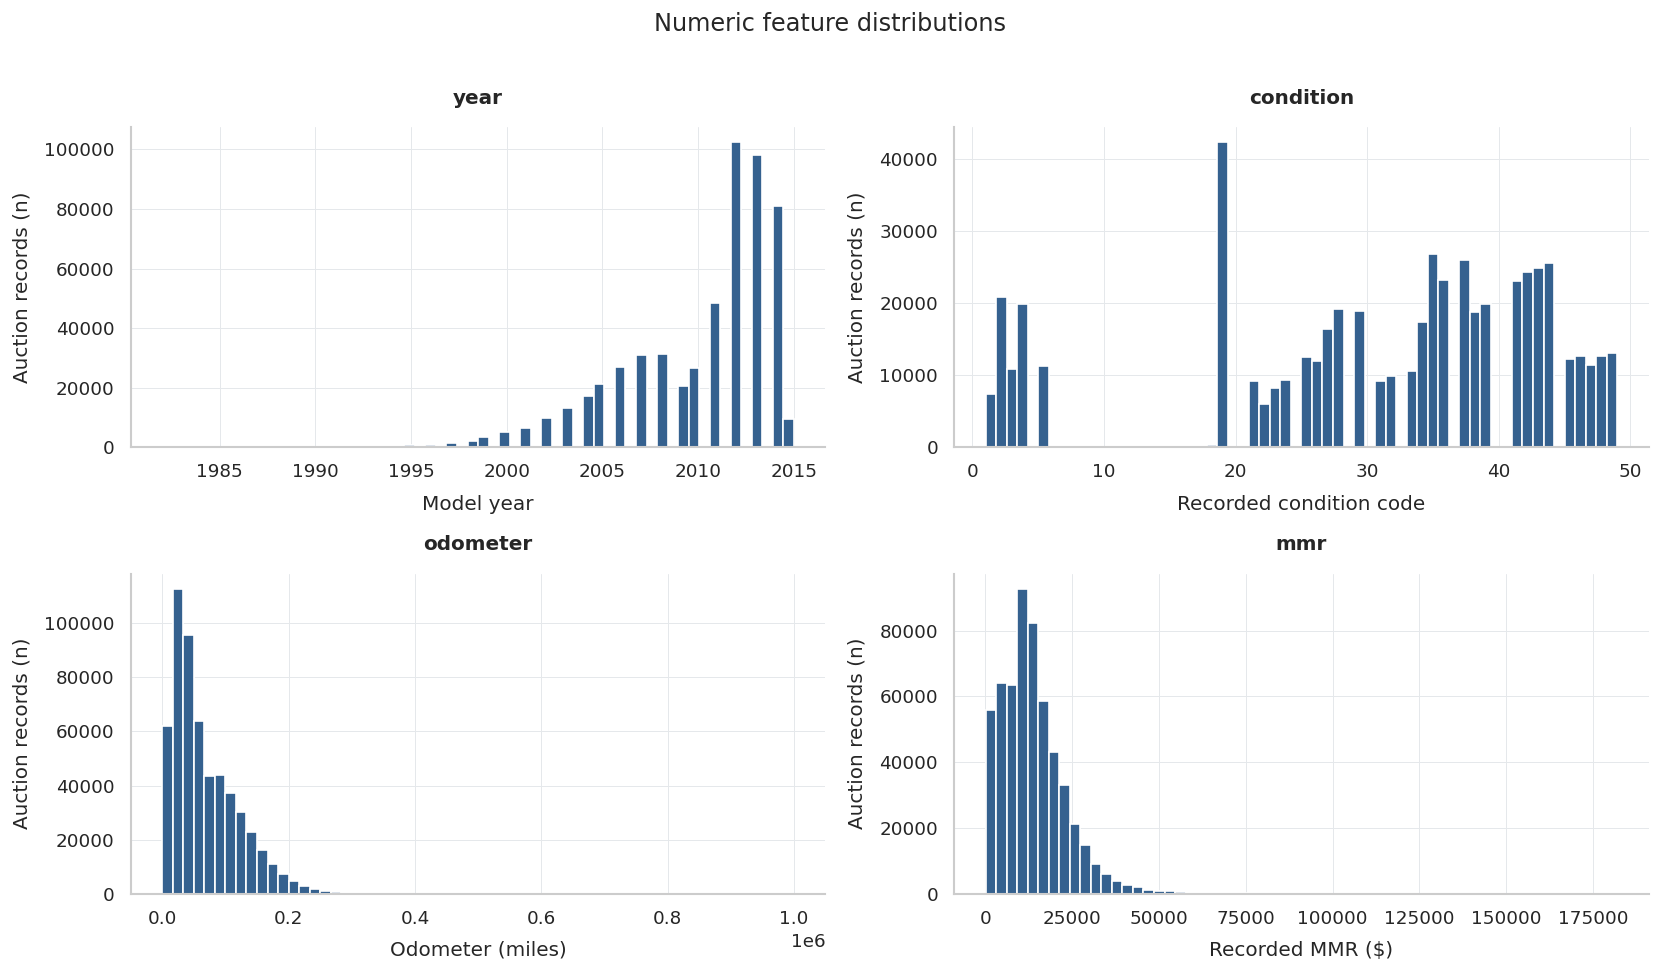

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.ravel(), ["year", "condition", "odometer", "mmr"], strict=True):
    ax.hist(cars[col].dropna(), bins=60, color="#35618F", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel(
        {
            "year": "Model year",
            "condition": "Recorded condition code",
            "odometer": "Odometer (miles)",
            "mmr": "Recorded MMR ($)",
        }[col]
    )
    ax.set_ylabel("Auction records (n)")
plt.suptitle("Numeric feature distributions", y=1.01)
plt.tight_layout()
plt.show()

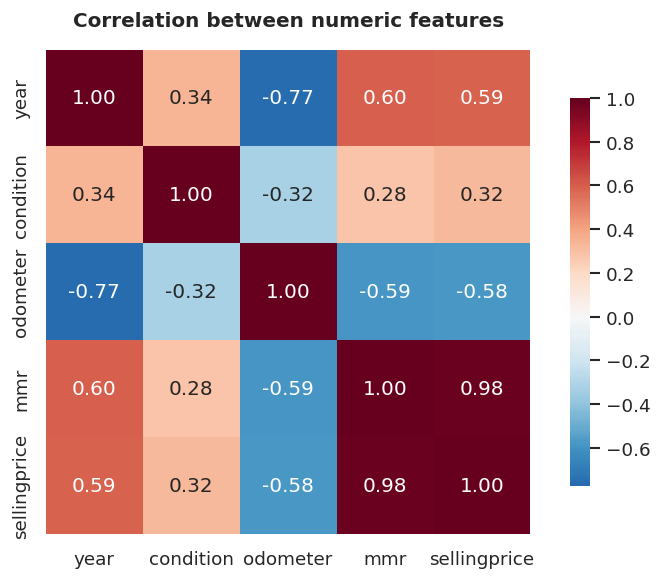

In [13]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    cars[num_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation between numeric features")
plt.tight_layout()
plt.show()

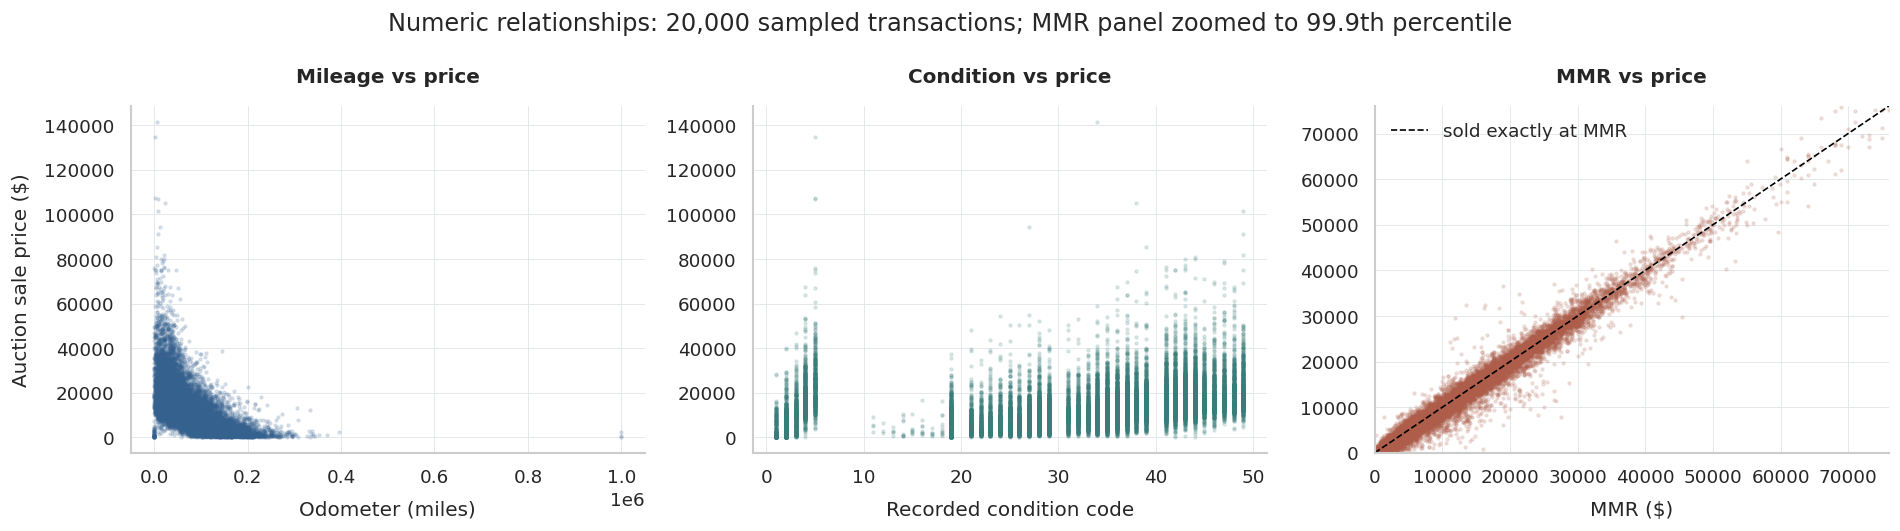

In [14]:
# Relationship between the main numeric drivers and price.
plot_pool = cars.dropna(subset=["sellingprice", "odometer", "condition", "mmr"])
sample = plot_pool.sample(min(20000, len(plot_pool)), random_state=SEED)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(
    sample["odometer"], sample["sellingprice"], s=3, alpha=0.15, color="#35618F"
)
axes[0].set_xlabel("Odometer (miles)")
axes[0].set_ylabel("Auction sale price ($)")
axes[0].set_title("Mileage vs price")

axes[1].scatter(
    sample["condition"], sample["sellingprice"], s=3, alpha=0.15, color="#387D7A"
)
axes[1].set_xlabel("Recorded condition code")
axes[1].set_title("Condition vs price")

axes[2].scatter(sample["mmr"], sample["sellingprice"], s=3, alpha=0.15, color="#AD5D49")
lims = [0, sample[["mmr", "sellingprice"]].quantile(0.999).max()]
axes[2].plot(lims, lims, "k--", linewidth=1, label="sold exactly at MMR")
axes[2].set_xlim(lims)
axes[2].set_ylim(lims)
axes[2].set_xlabel("MMR ($)")
axes[2].set_title("MMR vs price")
axes[2].legend()

fig.suptitle(
    f"Numeric relationships: {len(sample):,} sampled transactions; MMR panel zoomed to 99.9th percentile"
)
plt.tight_layout()
plt.show()

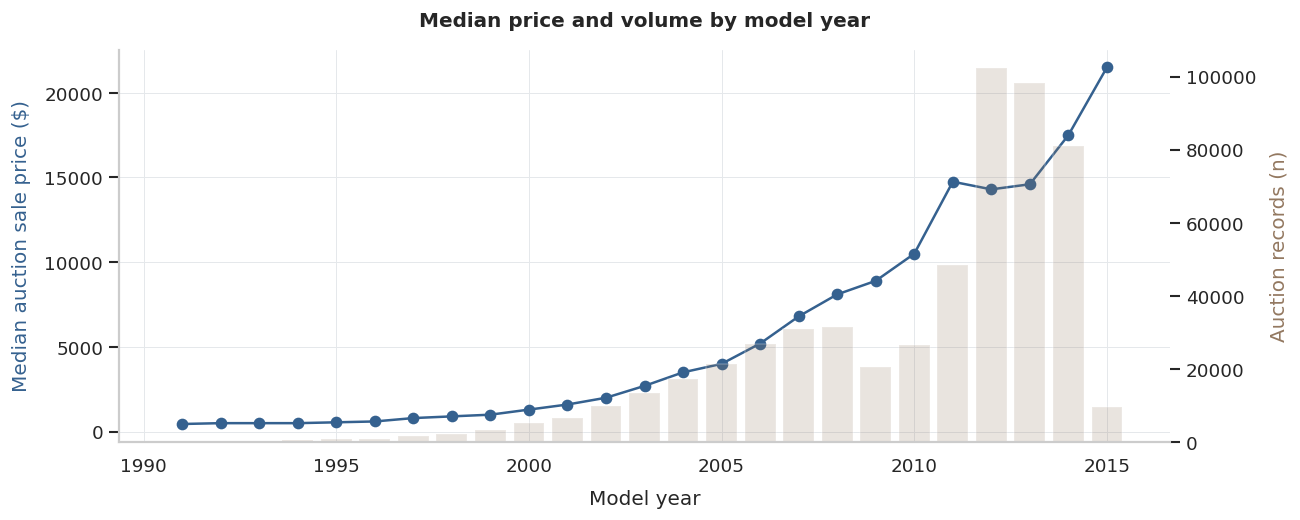

In [15]:
# Descriptive model-year comparison; mix and sale timing are not controlled.
by_year = cars.groupby("year")["sellingprice"].agg(["median", "count"])
by_year = by_year[by_year["count"] >= 50]

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.plot(by_year.index, by_year["median"], marker="o", color="#35618F")
ax1.set_xlabel("Model year")
ax1.set_ylabel("Median auction sale price ($)", color="#35618F")
ax2 = ax1.twinx()
ax2.bar(by_year.index, by_year["count"], alpha=0.2, color="#937860")
ax2.set_ylabel("Auction records (n)", color="#937860")
ax2.grid(False)
plt.title("Median price and volume by model year")
plt.tight_layout()
plt.show()

Mileage and price move in opposite directions, but not along a straight line: price falls steeply over the first stretch of miles and then flattens. A linear model would have to be told about that bend; a neural network or gradient boosting can learn it.

MMR and auction sale price line up closely around the diagonal (correlation about 0.98), which is what we would expect from a price guide built on auction sales. The spread around that diagonal is the opportunity in this project, and Section 6 measures it.

## 5. Category concentration and inconsistent labels shape preprocessing
Category counts are ranked by transaction frequency. Price comparisons use the same leading categories, so the distribution plots remain grounded in sample size. The table reports cardinality and the largest category's share among nonmissing values.

In [16]:
cat_cols = [
    "make",
    "model",
    "trim",
    "body",
    "transmission",
    "state",
    "color",
    "interior",
    "seller",
]

category_summary = []
for column in cat_cols:
    counts = cars[column].value_counts()
    category_summary.append(
        {
            "field": column,
            "unique_values": len(counts),
            "most_common": counts.index[0] if len(counts) else None,
            "top_share_pct": 100 * counts.iloc[0] / counts.sum() if len(counts) else np.nan,
        }
    )

category_summary = pd.DataFrame(category_summary)
category_summary = category_summary.sort_values("unique_values", ascending=False)
display(category_summary.round({"top_share_pct": 1}))

,field,unique_values,most_common,top_share_pct
8,seller,14263,nissan-infiniti lt,3.5
2,trim,1963,Base,10.2
1,model,973,Altima,3.5
0,make,96,Ford,17.1
3,body,87,Sedan,36.6
5,state,64,fl,14.8
6,color,46,black,19.9
7,interior,17,black,43.8
4,transmission,4,automatic,96.4


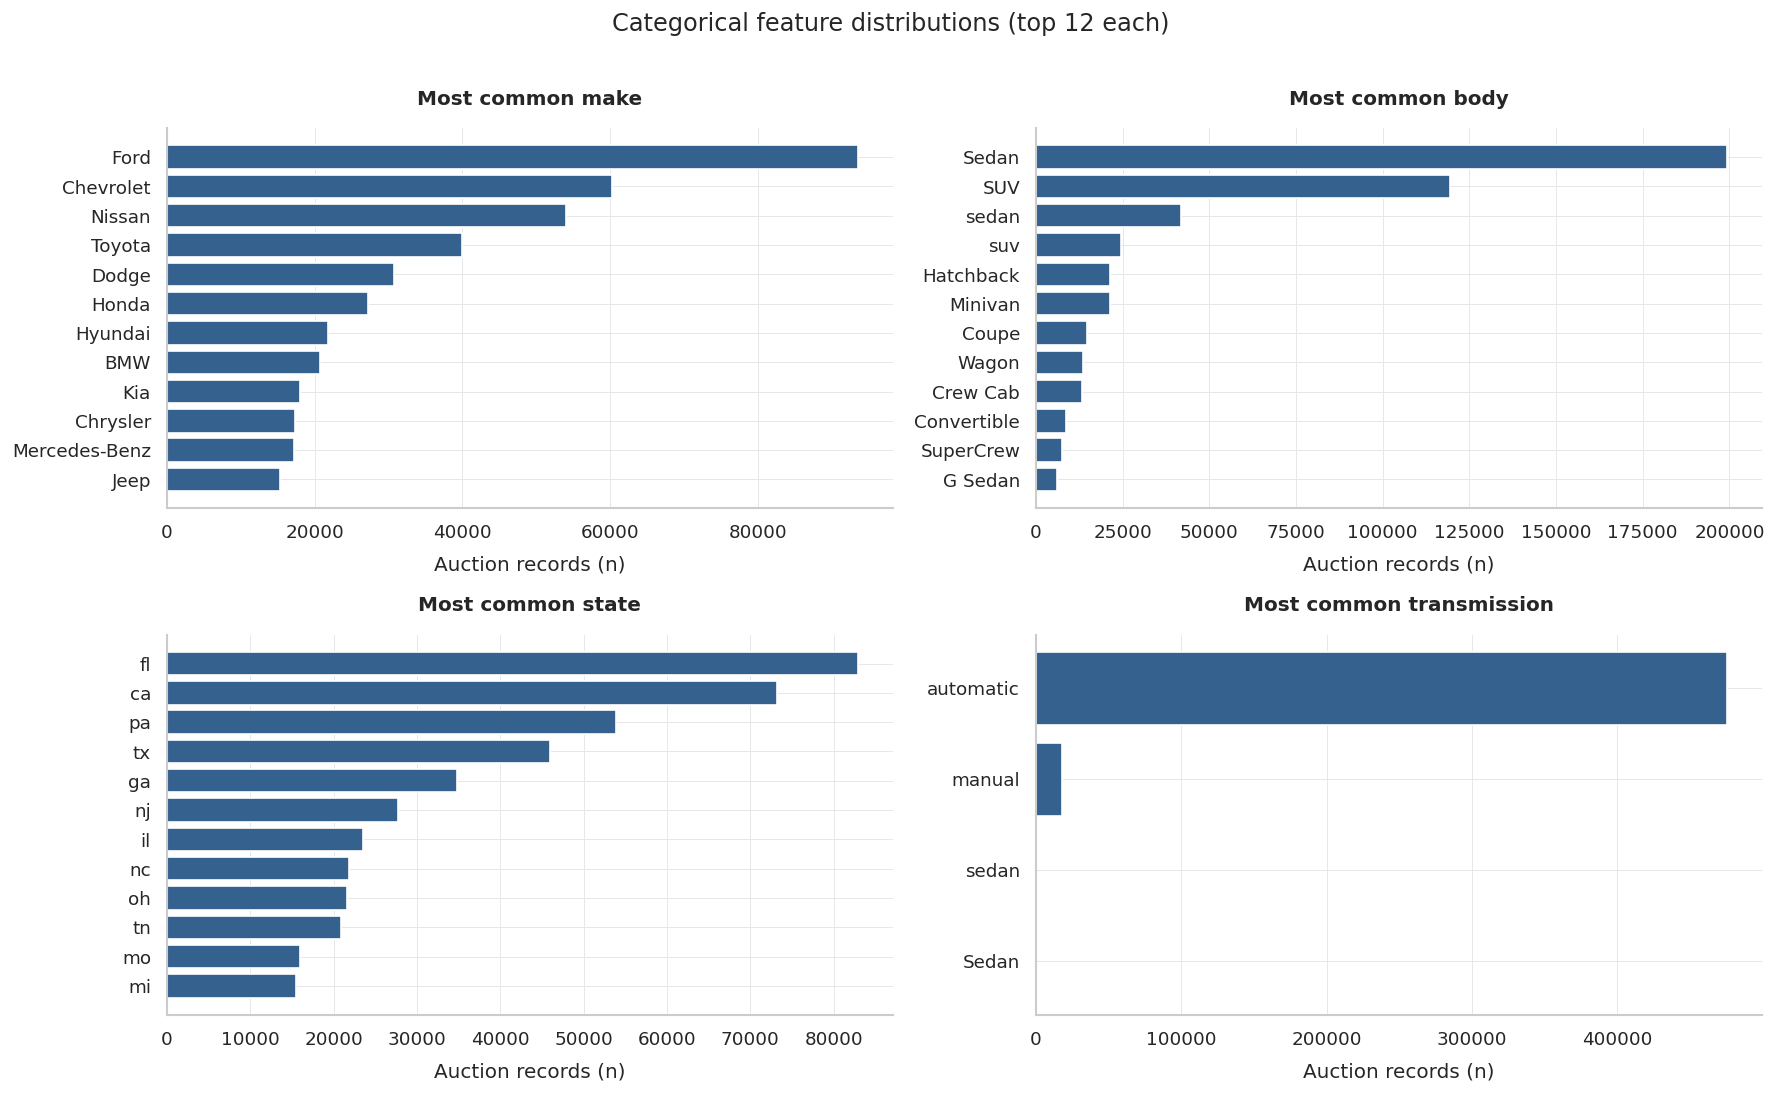

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, col in zip(axes.ravel(), ["make", "body", "state", "transmission"], strict=True):
    top = cars[col].value_counts().head(12)
    ax.barh(top.index[::-1], top.values[::-1], color="#35618F")
    ax.set_title(f"Most common {col}")
    ax.set_xlabel("Auction records (n)")
plt.suptitle("Categorical feature distributions (top 12 each)", y=1.01)
plt.tight_layout()
plt.show()

The raw labels are not clean. `body` has `Sedan` and `sedan` as separate values, and `transmission` contains body-style words (`sedan`, `Sedan`), which points to shifted columns in a few records. Is inconsistent casing limited to `body`? The next table checks every text field: how many distinct labels it has as written, and how many remain once case and stray spaces are ignored.

In [ ]:
casing_rows = []
for column in cat_cols:
    labels = cars[column].dropna().astype(str)
    raw_labels = labels.nunique()
    normalized_labels = labels.str.strip().str.lower().nunique()
    casing_rows.append(
        {
            "field": column,
            "labels_as_written": raw_labels,
            "labels_ignoring_case": normalized_labels,
            "labels_merged": raw_labels - normalized_labels,
        }
    )

casing_table = pd.DataFrame(casing_rows).set_index("field")
casing_table = casing_table.sort_values("labels_merged", ascending=False)
display(casing_table)

Any field with labels merged has the same value spelled more than one way. An encoder fitted on raw labels would treat those spellings as unrelated categories, so Stage 4 lowercases and trims every text field before encoding, fitted on training data only.

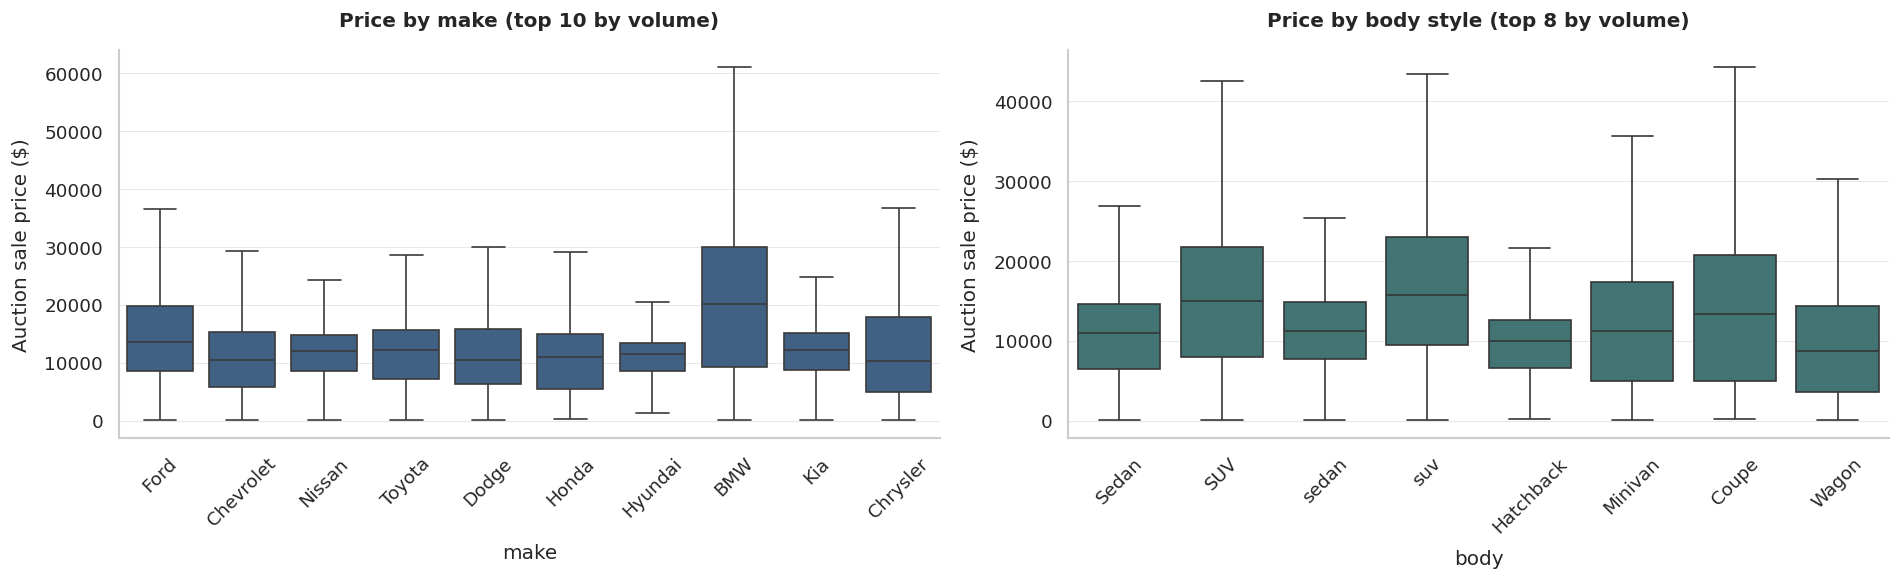

In [18]:
# Rank the same leading categories by record count in both price comparisons.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_makes = cars["make"].value_counts().head(10).index
sns.boxplot(
    data=cars[cars["make"].isin(top_makes)],
    x="make",
    y="sellingprice",
    ax=axes[0],
    order=list(top_makes),
    showfliers=False,
    color="#35618F",
)
axes[0].set_title("Price by make (top 10 by volume)")
axes[0].tick_params(axis="x", rotation=45)

top_bodies = cars["body"].value_counts().head(8).index
sns.boxplot(
    data=cars[cars["body"].isin(top_bodies)],
    x="body",
    y="sellingprice",
    ax=axes[1],
    order=list(top_bodies),
    showfliers=False,
    color="#387D7A",
)
axes[1].set_title("Price by body style (top 8 by volume)")
axes[1].tick_params(axis="x", rotation=45)

for ax in axes:
    ax.set_ylabel("Auction sale price ($)")
plt.tight_layout()
plt.show()

The cardinality table drives the encoding plan. `body`, `transmission` and `state` are small enough to one-hot encode directly, and `make` is borderline. `model`, `trim` and `seller` have hundreds to thousands of values, far too many for one-hot encoding, so the neural network will use learned embeddings for them.

`seller` is worth keeping despite its size. Different consignors have different reserve behavior and fleets, so who is selling the car plausibly carries price signal that MMR does not capture. Section 7 tests that.

## 6. MMR as a benchmark

In [19]:
benchmark = cars.dropna(subset=["sellingprice", "mmr"]).copy()
benchmark["error"] = benchmark["sellingprice"] - benchmark["mmr"]
benchmark["abs_error"] = benchmark["error"].abs()
benchmark["pct_error"] = benchmark["error"] / benchmark["mmr"].replace(0, np.nan) * 100

mae = benchmark["abs_error"].mean()
medae = benchmark["abs_error"].median()
bias = benchmark["error"].mean()
ratio = (benchmark["sellingprice"].sum() / benchmark["mmr"].sum()) * 100

print(f"Auction records compared:               {len(benchmark):,}")
print(f"MMR mean absolute error:         ${mae:,.0f}")
print(f"MMR median absolute error:       ${medae:,.0f}")
print(f"Mean signed error (bias):        ${bias:,.0f}")
print(f"Total sold / total MMR:          {ratio:.1f}%")
print()
print(f"Sold ABOVE MMR:  {(benchmark['error'] > 0).mean():.1%}")
print(f"Sold BELOW MMR:  {(benchmark['error'] < 0).mean():.1%}")
print()
for t in [500, 1000, 2000, 5000]:
    print(
        f"Off by more than ${t:,}: {(benchmark['abs_error'] > t).mean():.1%} of auction records"
    )

Auction records compared:               558,799
MMR mean absolute error:         $1,087
MMR median absolute error:       $700
Mean signed error (bias):        $-158
Total sold / total MMR:          98.9%

Sold ABOVE MMR:  46.7%
Sold BELOW MMR:  51.3%

Off by more than $500: 60.8% of auction records
Off by more than $1,000: 36.6% of auction records
Off by more than $2,000: 13.5% of auction records
Off by more than $5,000: 1.7% of auction records


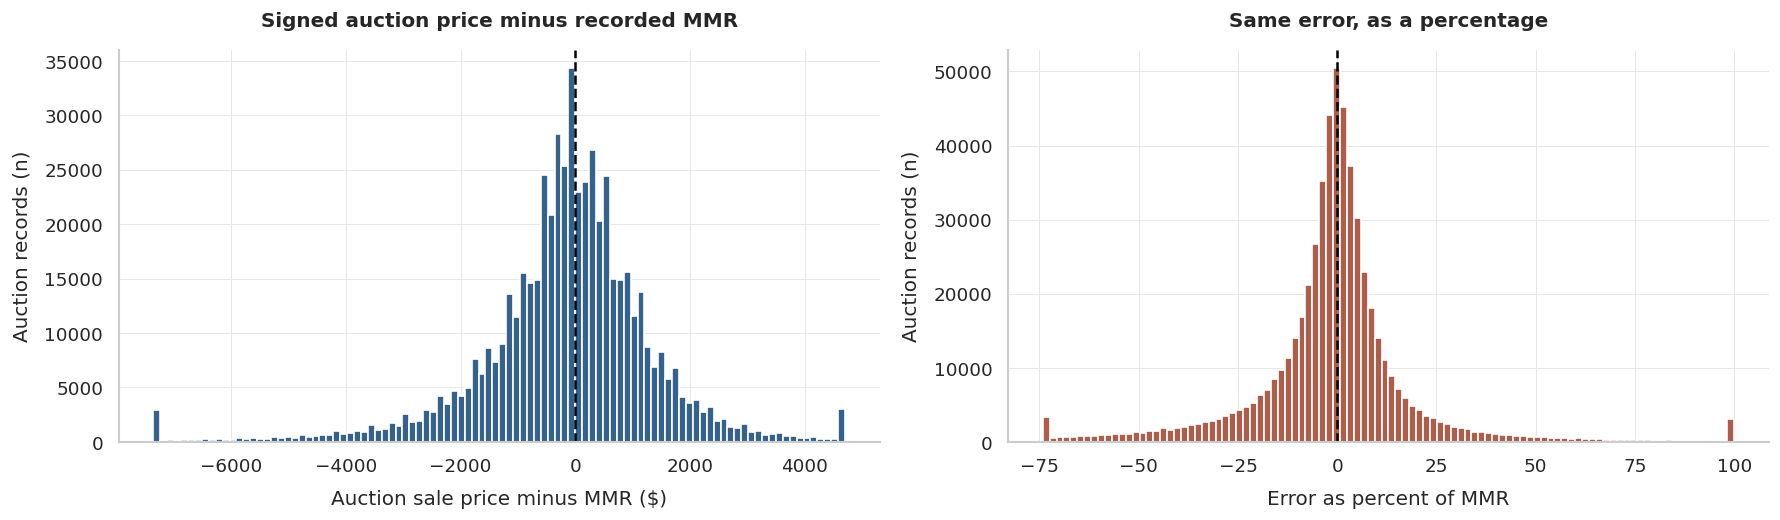

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

clip = benchmark["error"].quantile([0.005, 0.995])
axes[0].hist(benchmark["error"].clip(*clip), bins=100, color="#35618F", edgecolor="white")
axes[0].axvline(0, color="black", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Auction sale price minus MMR ($)")
axes[0].set_ylabel("Auction records (n)")
axes[0].set_title("Signed auction price minus recorded MMR")

pct_clip = benchmark["pct_error"].quantile([0.005, 0.995])
axes[1].hist(
    benchmark["pct_error"].clip(*pct_clip), bins=100, color="#AD5D49", edgecolor="white"
)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Error as percent of MMR")
axes[1].set_ylabel("Auction records (n)")
axes[1].set_title("Same error, as a percentage")

plt.tight_layout()
plt.show()

To keep the long tails from flattening the histograms, values beyond the 0.5th and 99.5th percentiles are drawn in the two edge bins.

,vehicles,mean_abs_error,median_mmr,error_as_pct_of_mmr
price_band,,,,
cheapest 20%,111978,786.0,3075.0,26.0
low,112056,1034.0,8475.0,12.0
mid,111523,970.0,12300.0,8.0
high,112397,1121.0,16750.0,7.0
priciest 20%,110845,1526.0,25600.0,6.0


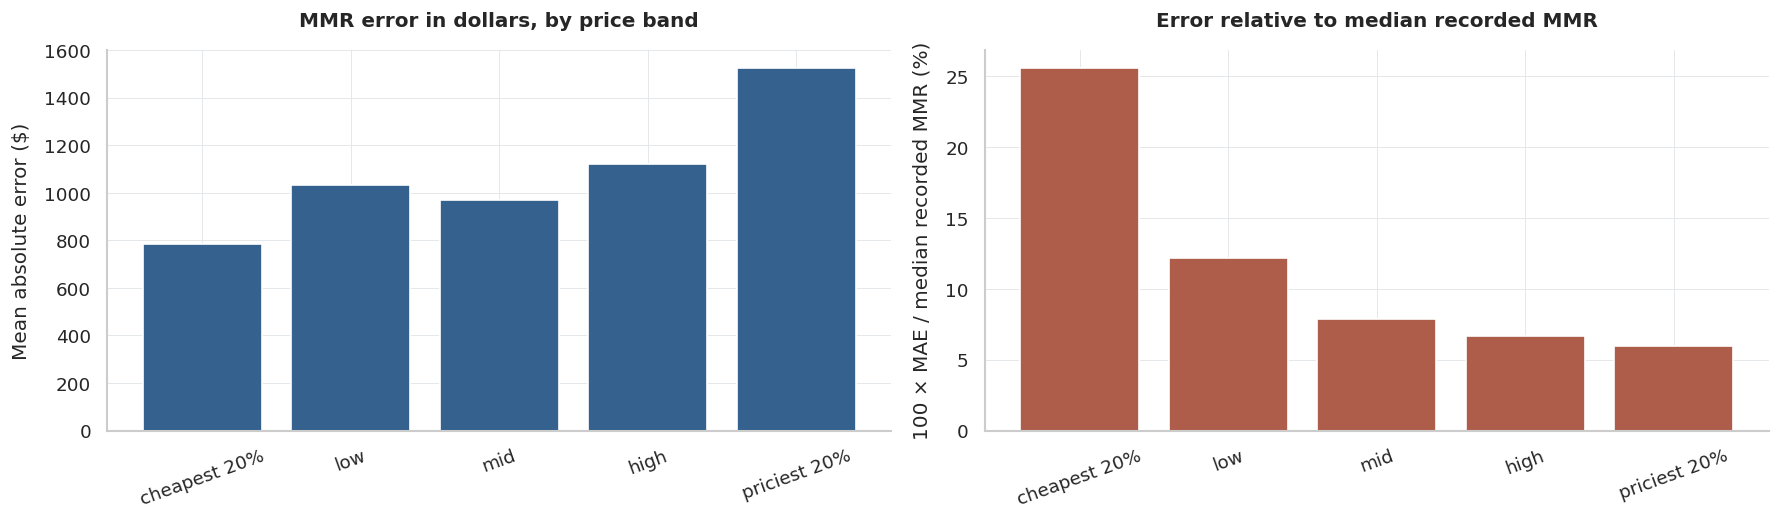

In [21]:
# Does MMR miss more on some kinds of vehicle than others?
benchmark["price_band"] = pd.qcut(
    benchmark["mmr"], 5, labels=["cheapest 20%", "low", "mid", "high", "priciest 20%"]
)

band = benchmark.groupby("price_band", observed=True).agg(
    vehicles=("abs_error", "size"),
    mean_abs_error=("abs_error", "mean"),
    median_mmr=("mmr", "median"),
)
band["error_as_pct_of_mmr"] = (band["mean_abs_error"] / band["median_mmr"] * 100).round(1)
display(band.round(0))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].bar(band.index.astype(str), band["mean_abs_error"], color="#35618F")
axes[0].set_ylabel("Mean absolute error ($)")
axes[0].set_title("MMR error in dollars, by price band")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(band.index.astype(str), band["error_as_pct_of_mmr"], color="#AD5D49")
axes[1].set_ylabel("100 × MAE / median recorded MMR (%)")
axes[1].set_title("Error relative to median recorded MMR")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

Each band is a quintile of recorded MMR, ordered low to high. The right panel is **100 × mean absolute dollar error / median MMR within the band**; it is not the mean of row-level percentage errors. The accompanying table gives the transaction counts.

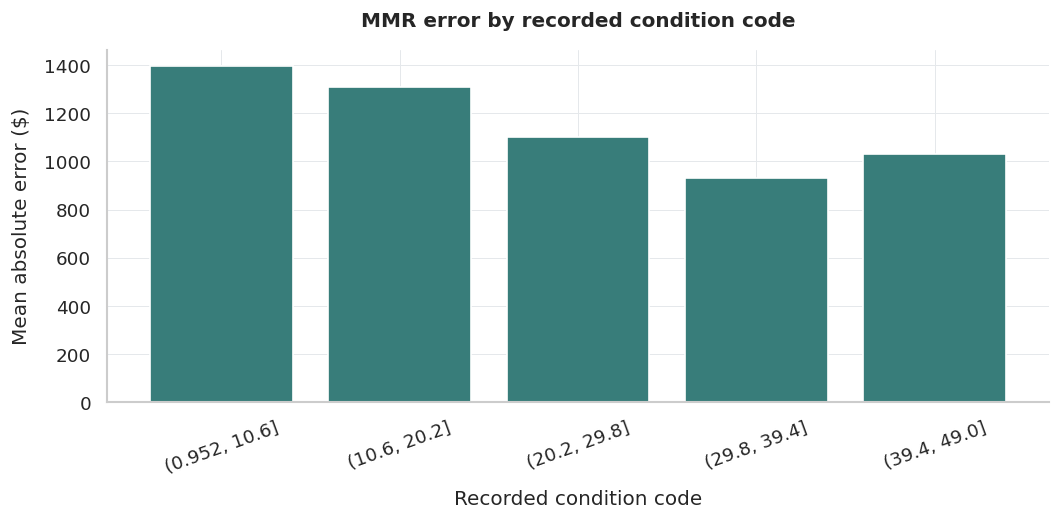

,mean,size
condition_bin,,
"(0.952, 10.6]",1396.0,70100
"(10.6, 20.2]",1310.0,43562
"(20.2, 29.8]",1103.0,111695
"(29.8, 39.4]",930.0,161675
"(39.4, 49.0]",1030.0,159973


In [22]:
# Error by recorded condition code: descriptive bins with unverified semantics.
cond = benchmark.dropna(subset=["condition"]).copy()
cond["condition_bin"] = pd.cut(cond["condition"], bins=5)
by_cond = cond.groupby("condition_bin", observed=True)["abs_error"].agg(["mean", "size"])

plt.figure(figsize=(9, 4.5))
plt.bar(by_cond.index.astype(str), by_cond["mean"], color="#387D7A")
plt.ylabel("Mean absolute error ($)")
plt.xlabel("Recorded condition code")
plt.title("MMR error by recorded condition code")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

display(by_cond.round(0))

### Which way does MMR miss on rough cars?
Absolute error says how far off MMR is, not which way. The chart below shows the median signed error (auction sale price minus MMR) for every condition code with at least 500 records. Below zero means cars with that code usually sell for less than their guide value.

In [ ]:
MIN_RECORDS_PER_CODE = 500

by_condition_code = (
    benchmark.dropna(subset=["condition"])
    .groupby("condition")["error"]
    .agg(median_signed_error="median", records="size")
)
by_condition_code = by_condition_code[by_condition_code["records"] >= MIN_RECORDS_PER_CODE]

# Color by direction so "sells below guide" and "sells above guide" separate at a glance.
bar_colors = np.where(by_condition_code["median_signed_error"] < 0, RUST, TEAL)

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(
    by_condition_code.index,
    by_condition_code["median_signed_error"],
    color=bar_colors,
    width=0.8,
)
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("Recorded condition code")
ax.set_ylabel("Median sale price minus MMR ($)")
ax.set_title("Median signed MMR error by condition code (red: sells below guide)")
format_dollar_axis(ax)
plt.tight_layout()
plt.show()

The five bins use the observed condition code, whose semantics remain unverified. Bin counts are shown in the table. The plot does not establish severity or causal damage effects.

This is the central finding of the auction analysis, and it confirms the premise of the project.

**In aggregate MMR looks excellent.** Total sales come to 98.9% of total MMR value and the mean signed error is only about \$158 below guide.

**Per vehicle the picture is different.** The mean absolute error is \$1,087 and the median is \$700. About 61% of vehicles miss their guide value by more than \$500, 36.6% by more than \$1,000, and 13.5% by more than \$2,000. Our proposal cited CarMax's profit of about \$317 per retail unit; the average MMR miss is more than three times that, so the typical error in the guide a buyer prices from is larger than the whole margin on the car.

**The error is uneven.** In dollars it grows with the value of the car, from \$786 in the cheapest fifth to \$1,526 in the priciest. Relative to value it runs the other way, from 26% down to 6%. And it is largest on rough cars: about \$1,396 for the lowest condition codes against \$930 in the middle of the scale. MMR is least reliable exactly where condition is worst, which is the case a damage detector reading photographs is built to catch.

These are retrospective comparisons: the source does not record when MMR was published relative to bidding.

## 7. Error by consignor

The dataset has no information about the dealer doing the buying, but it does identify the
consignor putting each car into the auction. That is the one seller-side field available, so it is
worth checking whether MMR is more reliable for some consignors than others.

In [23]:
# Does MMR miss more on cars from some consignors than others?
# Only sellers with enough volume to be meaningful.
seller_stats = benchmark.groupby("seller").agg(
    vehicles=("abs_error", "size"),
    mean_abs_error=("abs_error", "mean"),
    mean_signed_error=("error", "mean"),
    median_mmr=("mmr", "median"),
)
big_sellers = seller_stats[seller_stats["vehicles"] >= 200].copy()
big_sellers["error_pct_of_mmr"] = (
    big_sellers["mean_abs_error"] / big_sellers["median_mmr"] * 100
)

print(f"Sellers in the data:              {seller_stats.shape[0]:,}")
print(f"Sellers with 200+ sales:          {len(big_sellers):,}")
print(
    f"Share of all sales they account for: "
    f"{big_sellers['vehicles'].sum() / len(benchmark):.1%}"
)
print()
print("Spread in MMR error across these sellers:")
print(f"  lowest  mean abs error: ${big_sellers['mean_abs_error'].min():,.0f}")
print(f"  median  mean abs error: ${big_sellers['mean_abs_error'].median():,.0f}")
print(f"  highest mean abs error: ${big_sellers['mean_abs_error'].max():,.0f}")

Sellers in the data:              14,260
Sellers with 200+ sales:          313
Share of all sales they account for: 69.5%

Spread in MMR error across these sellers:
  lowest  mean abs error: $329
  median  mean abs error: $1,089
  highest mean abs error: $6,961


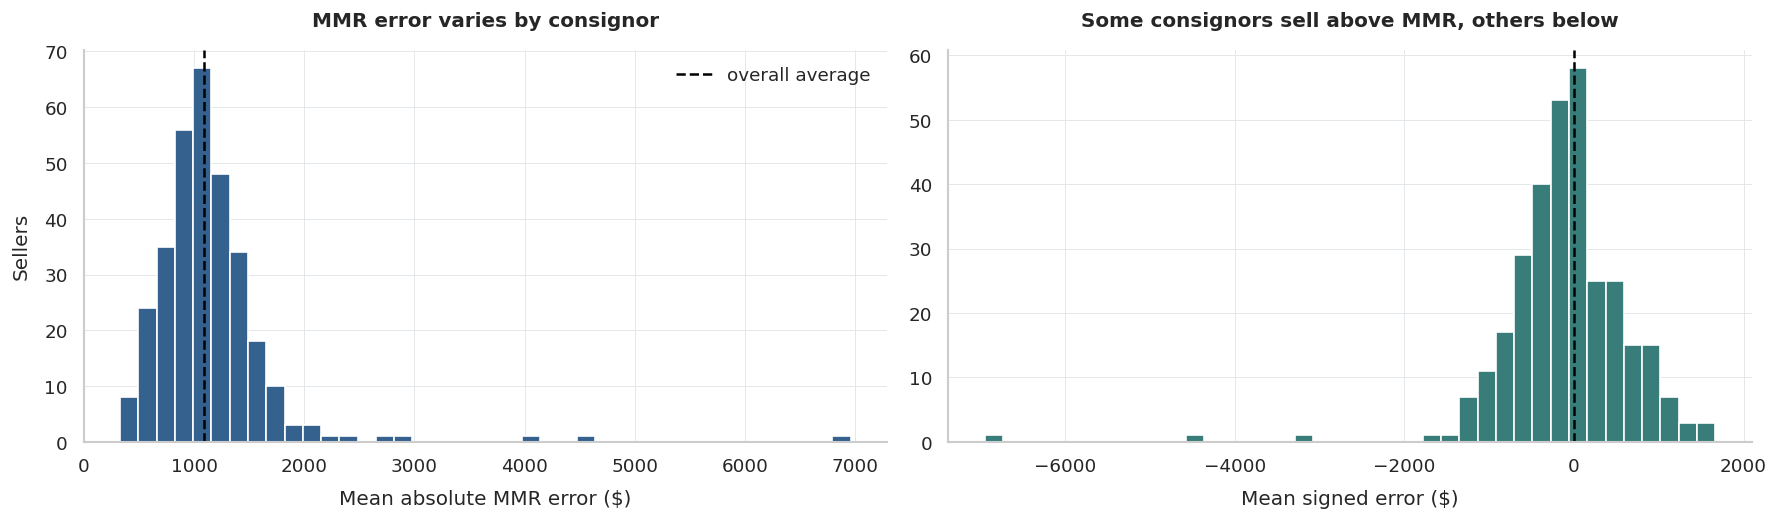

Ten consignors whose cars sell furthest above MMR on average:


,vehicles,mean_signed_error,mean_abs_error,median_mmr
seller,,,,
reliance motors llc,430,1664.0,1853.0,17650.0
vw credit prequalified,388,1540.0,1728.0,17075.0
aaero sweet company,1595,1455.0,1772.0,10000.0
san diego sports cars,305,1348.0,1628.0,9600.0
music city autoplex llc,997,1339.0,1601.0,22100.0
medlin buick gmc mazda,642,1307.0,1447.0,14100.0
kevins marysville auto sales inc,1116,1199.0,1451.0,13300.0
unique autos,844,1157.0,1491.0,14525.0
aaero sweet corporation,454,1126.0,1438.0,8788.0


Ten whose cars sell furthest below:


,vehicles,mean_signed_error,mean_abs_error,median_mmr
seller,,,,
hertz/tra,674,-6952.0,6961.0,13300.0
enterprise vehicle exchange / tra / rental / tulsa,3008,-4508.0,4524.0,14150.0
mercedes-benz usa,238,-3082.0,4096.0,36600.0
excell auto center,325,-1749.0,2097.0,23100.0
florida auto financial group,308,-1394.0,1611.0,14650.0
enterprise fleet management exchange inc.,417,-1332.0,1902.0,13450.0
innovate loan servicing corp,202,-1278.0,1411.0,5488.0
remarketing of america,246,-1223.0,1496.0,7500.0
td auto finance,1284,-1205.0,1742.0,12950.0


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

axes[0].hist(big_sellers["mean_abs_error"], bins=40, color="#35618F", edgecolor="white")
axes[0].axvline(
    benchmark["abs_error"].mean(),
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="overall average",
)
axes[0].set_xlabel("Mean absolute MMR error ($)")
axes[0].set_ylabel("Sellers")
axes[0].set_title("MMR error varies by consignor")
axes[0].legend()

axes[1].hist(big_sellers["mean_signed_error"], bins=40, color="#387D7A", edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Mean signed error ($)")
axes[1].set_title("Some consignors sell above MMR, others below")

plt.tight_layout()
plt.show()

print("Ten consignors whose cars sell furthest above MMR on average:")
display(
    big_sellers.nlargest(10, "mean_signed_error")[
        ["vehicles", "mean_signed_error", "mean_abs_error", "median_mmr"]
    ].round(0)
)

print("Ten whose cars sell furthest below:")
display(
    big_sellers.nsmallest(10, "mean_signed_error")[
        ["vehicles", "mean_signed_error", "mean_abs_error", "median_mmr"]
    ].round(0)
)

The consignor is the company putting the car into the auction, usually a lender, a rental company or a fleet. There is no buyer information in this dataset, so this is a one-sided view.

If MMR were equally accurate across consignors, these averages would sit near zero. They do not. Across the 313 consignors with at least 200 sales, which together account for about 70% of all sales, mean absolute error runs from \$329 to \$6,961, against an overall average of \$1,087. Rental, fleet and captive-finance sellers, including Hertz, two Enterprise entities, Mercedes-Benz USA and TD Auto Finance, sell well below guide, Hertz by nearly \$7,000 on average. Whatever drives that (reserve policy, vehicle history, presentation), MMR does not capture it, and it is visible from the seller field alone. That makes `seller` a strong candidate input, even though its size rules out one-hot encoding.

## 8. Observation volume and median price over time
Weekly counts describe records in this file, not total market sales. Sparse weeks provide less stable median estimates.

In [25]:
def parse_sale_dates(values):
    """Read the recorded calendar day without changing its timezone meaning."""
    # The source ends each date with a clock time and timezone description.
    calendar_dates = values.str.split(" ").str[:4].str.join(" ")
    return pd.to_datetime(calendar_dates, format="%a %b %d %Y", errors="coerce")


dated = cars.dropna(subset=["saledate"]).copy()
dated["sale_dt"] = parse_sale_dates(dated["saledate"])
print(f"Parsed dates: {dated['sale_dt'].notna().sum():,}")
print(f"Failed dates: {dated['sale_dt'].isna().sum():,}")

dated = dated.dropna(subset=["sale_dt"])
first_sale = dated["sale_dt"].min()
last_sale = dated["sale_dt"].max()
print(f"Date range: {first_sale.date()} to {last_sale.date()}")
print(f"Span: {(last_sale - first_sale).days:,} days")

Parsed dates: 558,799
Failed dates: 26
Date range: 2014-01-01 to 2015-07-21
Span: 566 days


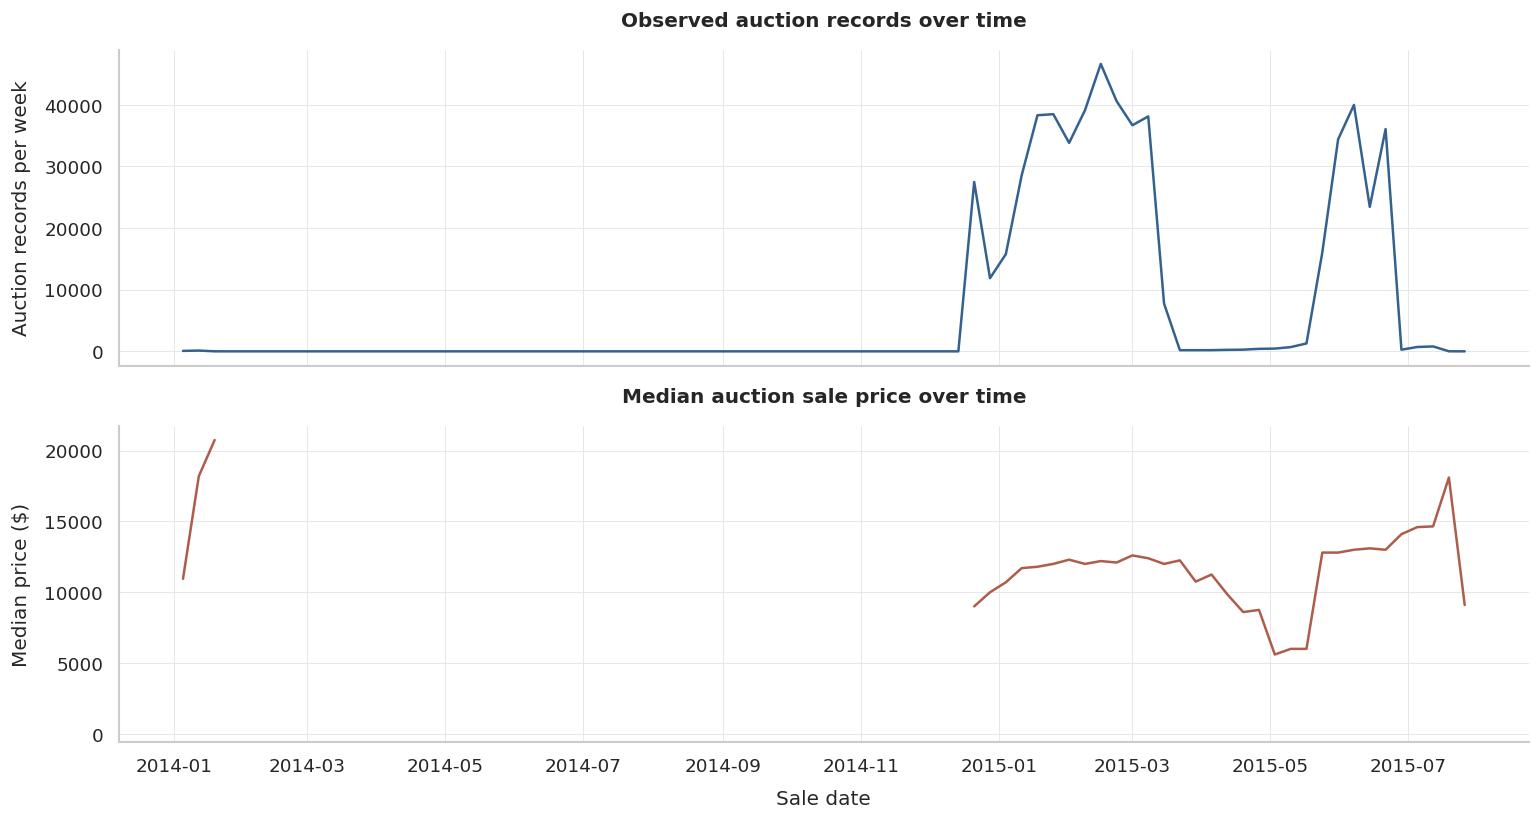

In [26]:
# Weeks with only a handful of sales give unstable medians, so we treat them separately.
MIN_RECORDS_PER_WEEK = 1_000
QUIET_GRAY = "#C9CED3"

weekly = (
    dated.set_index("sale_dt")
    .resample("W")["sellingprice"]
    .agg(records="size", median_price="median")
)
is_busy_week = weekly["records"] >= MIN_RECORDS_PER_WEEK
busy_weeks = weekly[is_busy_week]
quiet_weeks = weekly[~is_busy_week & (weekly["records"] > 0)]

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# Bars make empty and quiet stretches obvious; a line would draw straight across them.
axes[0].bar(
    weekly.index, weekly["records"], width=6, color=np.where(is_busy_week, BLUE, QUIET_GRAY)
)
axes[0].axhline(MIN_RECORDS_PER_WEEK, color="black", linestyle=":", linewidth=1)
axes[0].set_ylabel("Auction records per week")
axes[0].set_title(f"Weekly volume (gray: fewer than {MIN_RECORDS_PER_WEEK:,} records)")

axes[1].plot(
    busy_weeks.index,
    busy_weeks["median_price"],
    marker="o",
    markersize=3,
    color=RUST,
    label=f"weeks with {MIN_RECORDS_PER_WEEK:,}+ records",
)
axes[1].scatter(
    quiet_weeks.index,
    quiet_weeks["median_price"],
    s=14,
    facecolors="none",
    edgecolors="gray",
    label=f"weeks with fewer than {MIN_RECORDS_PER_WEEK:,} records",
)
axes[1].set_ylabel("Median auction sale price ($)")
axes[1].set_xlabel("Week of sale")
axes[1].set_title("Weekly median price: trust the solid line, not the faded points")
axes[1].legend(loc="lower left")
format_dollar_axis(axes[1])

plt.tight_layout()
plt.show()

# The same story in numbers: records per calendar month.
monthly_records = dated.set_index("sale_dt").resample("MS").size().rename("auction_records")
monthly_records.index = monthly_records.index.strftime("%Y-%m")
display(monthly_records.to_frame().T)

**Coverage is very uneven.** Apart from a few records in January 2014, the file is nearly empty until late December 2014, and the busy weeks come in bursts (see the monthly table). The dates span 566 days, but the effective window is much shorter. This is how the file was collected, not a picture of the whole market.

**Medians from quiet weeks are unreliable.** The largest swings in weekly median price fall in weeks with fewer than 1,000 records (faded points). Busy weeks are far more stable, and some drift between them may reflect which vehicles were sold as much as market prices.

Price level is not what a prediction range calibrates on, though. The range is built around MMR's error, so the next chart asks whether that error drifts.

In [ ]:
# Same busy-week rule, so every point rests on at least 1,000 sales.
dated_benchmark = benchmark.assign(sale_dt=parse_sale_dates(benchmark["saledate"]))
dated_benchmark = dated_benchmark.dropna(subset=["sale_dt"])

weekly_error = (
    dated_benchmark.set_index("sale_dt")
    .resample("W")
    .agg(
        records=("error", "size"),
        mean_abs_error=("abs_error", "mean"),
        median_signed_error=("error", "median"),
    )
)
weekly_error = weekly_error[weekly_error["records"] >= MIN_RECORDS_PER_WEEK]

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(
    weekly_error.index, weekly_error["mean_abs_error"], marker="o", markersize=3, color=BLUE
)
axes[0].axhline(
    benchmark["abs_error"].mean(),
    color="black",
    linestyle="--",
    linewidth=1,
    label="all records",
)
axes[0].set_ylabel("Mean absolute error ($)")
axes[0].set_title("How far MMR misses, week by week (busy weeks only)")
axes[0].legend(loc="upper left")
format_dollar_axis(axes[0])

axes[1].plot(
    weekly_error.index,
    weekly_error["median_signed_error"],
    marker="o",
    markersize=3,
    color=RUST,
)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_ylabel("Median sale price minus MMR ($)")
axes[1].set_xlabel("Week of sale")
axes[1].set_title("Which way MMR misses, week by week (below zero: cars sell under guide)")
format_dollar_axis(axes[1])

plt.tight_layout()
plt.show()

If MMR's error moved over time, a prediction range calibrated once on early sales would drift out of calibration on later ones. That is the comparison between fixed and adaptive ranges in our second research question, and these two lines are the quantity it depends on.

## 9. Cleaning decisions

In [27]:
def exclude_records(frame, mask, reason, audit):
    """Return the remaining records and append one sequential audit entry."""
    remaining = frame.loc[~mask].copy()
    audit.append(
        {
            "reason": reason,
            "rows_removed": len(frame) - len(remaining),
            "rows_remaining": len(remaining),
        }
    )
    return remaining


def clean_auction_data(raw):
    """Apply the existing study rules without mutating the source table."""
    cleaned = raw.copy()
    audit = []

    # Apply exclusions in the original order so their counts remain comparable.
    rules = [
        ("missing sellingprice or mmr", raw["sellingprice"].isna() | raw["mmr"].isna()),
        ("missing both make and model", raw["make"].isna() & raw["model"].isna()),
        ("missing saledate", raw["saledate"].isna()),
        ("auction sale price at or below $100", raw["sellingprice"] <= 100),
        ("recorded MMR at or below $100", raw["mmr"] <= 100),
        ("odometer above 500,000 miles", raw["odometer"] > 500_000),
    ]
    for reason, mask in rules:
        cleaned = exclude_records(cleaned, mask.loc[cleaned.index], reason, audit)

    # Repeated keys do not independently prove duplicate physical sale events.
    repeated_keys = cleaned.duplicated(["vin", "saledate"], keep="first")
    cleaned = exclude_records(cleaned, repeated_keys, "repeated VIN and sale date", audit)
    cleaned["transmission"] = cleaned["transmission"].fillna("unknown")
    cleaned["sale_dt"] = parse_sale_dates(cleaned["saledate"])
    cleaned = exclude_records(
        cleaned, cleaned["sale_dt"].isna(), "unparseable sale date", audit
    )

    # Minus one allows next-model-year vehicles under the existing study rule.
    cleaned["age_at_sale"] = cleaned["sale_dt"].dt.year - cleaned["year"]
    invalid_age = ~cleaned["age_at_sale"].between(-1, 50)
    cleaned = exclude_records(cleaned, invalid_age, "age outside -1 to 50 years", audit)
    return cleaned, pd.DataFrame(audit)

In [28]:
clean, cleaning_audit = clean_auction_data(cars)
display(cleaning_audit)
print(
    f"Retained {len(clean):,} of {len(cars):,} auction records ({len(clean) / len(cars):.1%})."
)

preview_columns = [
    "year",
    "age_at_sale",
    "odometer",
    "condition",
    "mmr",
    "sellingprice",
    "sale_dt",
]
display(clean[preview_columns].head())

# Every exclusion should reconcile to the final cohort size.
assert cleaning_audit["rows_removed"].sum() + len(clean) == len(cars)

,reason,rows_removed,rows_remaining
0,missing sellingprice or mmr,38,558799
1,missing both make and model,10301,548498
2,missing saledate,0,548498
3,auction sale price at or below $100,21,548477
4,recorded MMR at or below $100,120,548357
5,"odometer above 500,000 miles",72,548285
6,repeated VIN and sale date,83,548202
7,unparseable sale date,0,548202
8,age outside -1 to 50 years,0,548202


Retained 548,202 of 558,837 auction records (98.1%).


,year,age_at_sale,odometer,condition,mmr,sellingprice,sale_dt
0,2015,-1,16639.0,5.0,20500.0,21500.0,2014-12-16
1,2015,-1,9393.0,5.0,20800.0,21500.0,2014-12-16
2,2014,1,1331.0,45.0,31900.0,30000.0,2015-01-15
3,2015,0,14282.0,41.0,27500.0,27750.0,2015-01-29
4,2014,0,2641.0,43.0,66000.0,67000.0,2014-12-18


Each removal has a specific reason rather than a blanket `dropna()`, and the audit table reconciles to the final count: 548,202 of 558,837 records (98.1%) are kept.

Records missing the target or the benchmark cannot be used or scored. Records missing both make and model describe no identifiable vehicle. Prices at or below \$100 are not plausible auction sales, and odometers above 500,000 miles are not credible readings. A repeated VIN on the same sale date is kept once so a single sale is not counted twice. Missing `transmission` becomes "unknown".

The one engineered feature is `age_at_sale`, sale year minus model year. A 2010 model means something different in a 2014 sale than in a 2015 one, and age is what drives depreciation. An age of −1 is a next-model-year vehicle sold early.

## 10. Train, validation and test split
The split is chronological: the oldest 70% of records for training, the next 15% for validation and for calibrating the prediction range, and the newest 15% held out for testing. A random split would let the model learn from sales after the test period, information no buyer has when bidding, and would make results look better than they are.

Each sale day is kept whole, with boundaries at the day closest to 70% and 85% of records, so no day is split between two partitions.

In [29]:
def split_by_sale_day(frame, train_share=0.70, validation_end_share=0.85):
    """Choose the nearest cumulative boundaries while keeping whole days intact."""
    if not 0 < train_share < validation_end_share < 1:
        raise ValueError("Split boundaries must satisfy 0 < train < validation end < 1.")

    ordered = frame.sort_values("sale_dt", kind="stable").reset_index(drop=True)
    day_counts = ordered.groupby("sale_dt", sort=True).size()
    if len(day_counts) < 3:
        raise ValueError("At least three sale days are needed for three partitions.")

    cumulative_counts = day_counts.cumsum().to_numpy()
    # Reserve at least one complete day for both validation and test.
    train_distance = np.abs(cumulative_counts[:-2] - train_share * len(ordered))
    train_position = int(np.argmin(train_distance))
    validation_positions = np.arange(train_position + 1, len(day_counts) - 1)
    validation_distance = np.abs(
        cumulative_counts[validation_positions] - validation_end_share * len(ordered)
    )
    validation_position = validation_positions[np.argmin(validation_distance)]
    train_end = day_counts.index[train_position]
    validation_end = day_counts.index[validation_position]

    partitions = {
        "train": ordered.loc[ordered["sale_dt"] <= train_end].copy(),
        "validation": ordered.loc[
            ordered["sale_dt"].between(train_end, validation_end, inclusive="right")
        ].copy(),
        "test": ordered.loc[ordered["sale_dt"] > validation_end].copy(),
    }
    return ordered, partitions


clean, split_frames = split_by_sale_day(clean)
train = split_frames["train"]
val = split_frames["validation"]
test = split_frames["test"]

In [30]:
# Partitions must not overlap in time and must account for every cleaned record.
assert train["sale_dt"].max() < val["sale_dt"].min()
assert val["sale_dt"].max() < test["sale_dt"].min()
assert len(train) + len(val) + len(test) == len(clean)

split_frames = {"train": train, "validation": val, "test": test}
split_rows = []
for split_name, frame in split_frames.items():
    split_rows.append(
        {
            "split": split_name,
            "auction_records": f"{len(frame):,}",
            "share": f"{len(frame) / len(clean):.1%}",
            "first_sale": frame["sale_dt"].min().date(),
            "last_sale": frame["sale_dt"].max().date(),
            "median_price": f"${frame['sellingprice'].median():,.0f}",
            "mmr_mean_abs_error": f"${(frame['sellingprice'] - frame['mmr']).abs().mean():,.0f}",
        }
    )
display(pd.DataFrame(split_rows).set_index("split"))

,split,rows,share,first_sale,last_sale
0,train,384673,0.702,2014-01-01,2015-03-05
1,validation,77205,0.141,2015-03-06,2015-06-02
2,test,86324,0.157,2015-06-03,2015-07-21


Known-vehicle overlaps: {'train_validation': 838, 'train_test': 493, 'validation_test': 483}
Future-sale holdout; not vehicle-disjoint. Vehicle identifiers must not be model features.


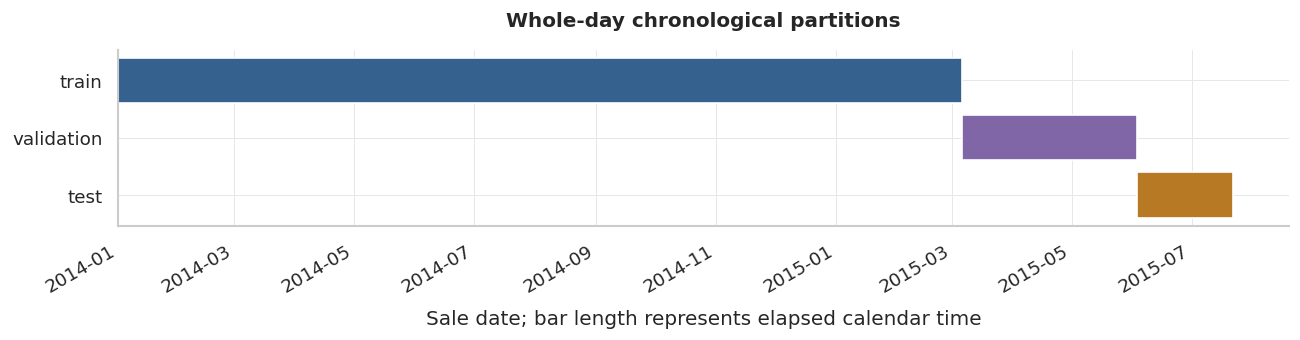

In [31]:
# One bar per sale day, colored by the partition that day belongs to.
fig, ax = plt.subplots(figsize=(13, 3.8))
for split_name, frame in split_frames.items():
    records_per_day = frame.groupby("sale_dt").size()
    ax.bar(
        records_per_day.index,
        records_per_day.values,
        width=1.0,
        color=SPLIT_COLORS[split_name],
        label=f"{split_name} ({len(frame):,} records)",
    )

ax.set_ylabel("Auction records per day")
ax.set_xlabel("Sale date")
ax.set_title("The split is chronological: the model is always tested on later sales")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3)
plt.tight_layout()
plt.show()


# A later sale date does not mean a different car: count vehicles resold across the boundary.
def normalized_vins(frame):
    vins = frame["vin"].dropna().astype(str).str.strip().str.upper()
    return set(vins[vins != ""])


train_vins = normalized_vins(train)
test_vins = test["vin"].dropna().astype(str).str.strip().str.upper()
resold_in_test = test_vins.isin(train_vins).sum()
print(
    f"Test records whose VIN also appears in training: {resold_in_test:,} of {len(test):,} "
    f"({resold_in_test / len(test):.1%})"
)

Training spans the most calendar time, but most of its records come from the winter burst. Validation falls largely in the quieter spring stretch and test in the summer burst, so equal shares of records do not mean equal stretches of time. A small share of test records are resales of vehicles already seen in training; the split is a future-sales holdout, not a vehicle-disjoint one, so VIN is never used as a feature.

### Do the three partitions look alike?
Same fields, same scales. This is a descriptive check only; nothing here is used to tune a model.

In [32]:
split_summary = []
for split_name, frame in split_frames.items():
    for field in ["sellingprice", "odometer", "age_at_sale"]:
        values = frame[field].dropna()
        split_summary.append(
            {
                "split": split_name,
                "field": field,
                "records": len(frame),
                "nonmissing": len(values),
                "missing_pct": 100 * frame[field].isna().mean(),
                "median": values.median(),
                "q25": values.quantile(0.25),
                "q75": values.quantile(0.75),
                "p99": values.quantile(0.99),
            }
        )
display(pd.DataFrame(split_summary).round(2))

,split,field,records,nonmissing,missing_pct,median,q25,q75,p99
0,train,sellingprice,384673,384673,0.00,11900.0,6500.00,17800.00,43000.00
1,train,odometer,384673,384594,0.02,54302.0,28768.25,102057.75,227763.12
2,train,age_at_sale,384673,384673,0.00,3.0,2.00,8.00,17.00
3,validation,sellingprice,77205,77205,0.00,12600.0,7700.00,18900.00,48200.00
4,validation,odometer,77205,77202,0.00,48530.0,27849.00,93276.25,218476.41
5,validation,age_at_sale,77205,77205,0.00,3.0,2.00,7.00,16.00
6,test,sellingprice,86324,86324,0.00,13300.0,8900.75,19800.00,50000.00
7,test,odometer,86324,86317,0.01,44873.0,25962.00,80549.00,205826.76
8,test,age_at_sale,86324,86324,0.00,3.0,2.00,5.00,15.00


### Compare distributions on common scales

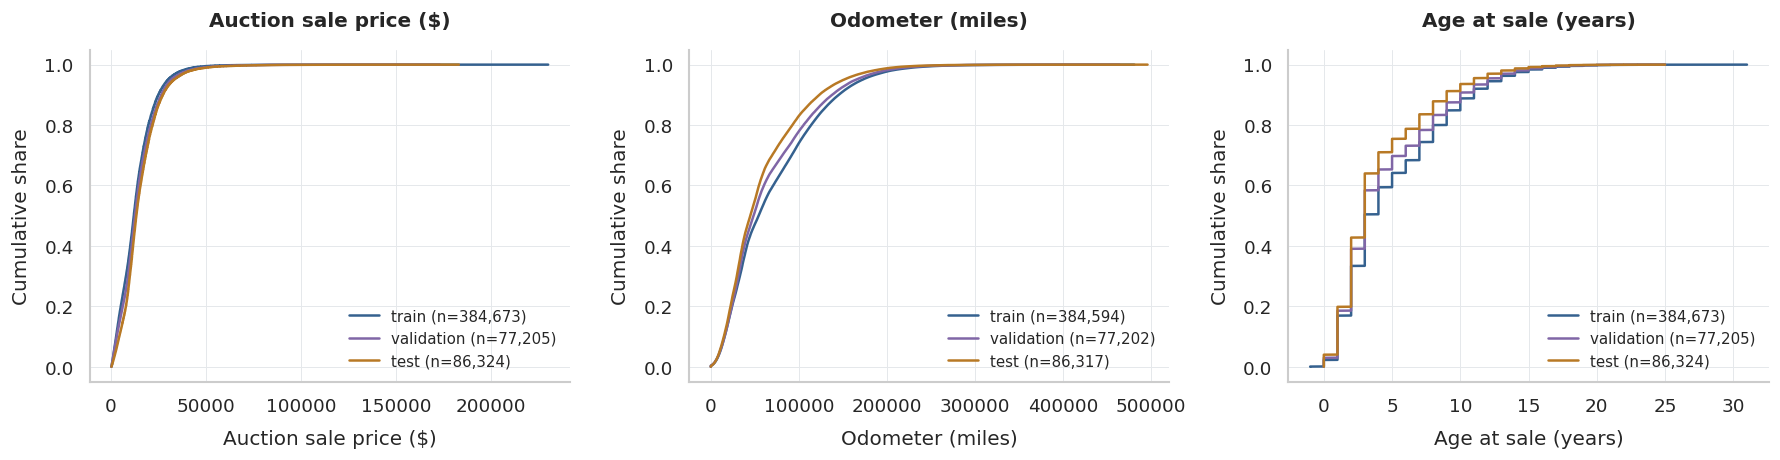

In [33]:
field_labels = {
    "sellingprice": "Auction sale price ($)",
    "odometer": "Odometer (miles)",
    "age_at_sale": "Age at sale (years)",
}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, (field, label) in zip(axes, field_labels.items(), strict=True):
    for split_name, frame in split_frames.items():
        values = np.sort(frame[field].dropna().to_numpy())
        cumulative_share = np.arange(1, len(values) + 1) / len(values)
        axis.plot(
            values,
            cumulative_share,
            label=f"{split_name} (n={len(values):,})",
            color=SPLIT_COLORS[split_name],
        )
    axis.set(xlabel=label, ylabel="Cumulative share", title=label)
    axis.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Body-style labels change spelling over time
The same body style is written two ways in this file: Capitalized (`Sedan`, `SUV`) and lowercase (`sedan`, `suv`). The chart shows which spelling each partition uses.

In [ ]:
CASE_COLORS = {
    "Capitalized (Sedan, SUV)": BLUE,
    "lowercase (sedan, suv)": RUST,
    "missing": "#C9CED3",
}


def body_label_case(labels):
    """Label each record's body style as Capitalized, lowercase, or missing."""
    case = pd.Series("Capitalized (Sedan, SUV)", index=labels.index)
    case[labels.fillna("").str.islower()] = "lowercase (sedan, suv)"
    case[labels.isna()] = "missing"
    return case


case_shares = (
    pd.DataFrame(
        {
            split_name: 100 * body_label_case(frame["body"]).value_counts(normalize=True)
            for split_name, frame in split_frames.items()
        }
    )
    .T.reindex(columns=list(CASE_COLORS))
    .fillna(0)
)
display(case_shares.round(1))

ax = case_shares.plot.barh(
    stacked=True, color=list(CASE_COLORS.values()), figsize=(11, 3.4), width=0.7
)
ax.invert_yaxis()  # train on top, in time order
ax.set_xlim(0, 100)
ax.set_xlabel("Percent of auction records in the partition")
ax.set_ylabel("")
ax.set_title("Body-style labels switch from Capitalized to lowercase over time")
ax.legend(
    title="How the body label is written",
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.32),
)

# Print the share inside each segment that is wide enough to hold it.
for segment in ax.containers:
    labels = [f"{value:.0f}%" if value >= 5 else "" for value in segment.datavalues]
    ax.bar_label(
        segment, labels=labels, label_type="center", color="white", fontweight="semibold"
    )

plt.tight_layout()
plt.show()

# How much of the "new" test vocabulary is only a spelling difference?
training_labels = set(train["body"].dropna())
training_labels_lower = {label.strip().lower() for label in training_labels}
test_labels = test["body"].dropna()
unseen_as_written = (~test_labels.isin(training_labels)).sum() / len(test)
unseen_after_lowercase = (
    ~test_labels.str.strip().str.lower().isin(training_labels_lower)
).sum() / len(test)
print(
    f"Test records whose body label never appears in training: {unseen_as_written:.1%} as written, "
    f"{unseen_after_lowercase:.3%} after lowercasing"
)

Training labels are mostly Capitalized; test labels are mostly lowercase. They are the same body styles spelled differently: about 20% of test records use a label never seen in training as written, and almost none do once labels are lowercased. Our saved encoder keeps case, so it treats `Sedan` and `sedan` as different categories. Lowercasing labels before encoding is a Stage 4 preprocessing fix.

### The benchmark to beat
Recorded MMR scored on the test split. Every later model is compared on exactly these records.

In [ ]:
# Retrospective benchmark: we do not know whether MMR was published before bidding.
test_errors = test["sellingprice"] - test["mmr"]

test_benchmark = pd.Series(
    {
        "Auction records in the test split": f"{len(test):,}",
        "Mean absolute error": f"${test_errors.abs().mean():,.0f}",
        "Median absolute error": f"${test_errors.abs().median():,.0f}",
        "Mean |error| as a percent of recorded MMR": f"{(100 * test_errors.abs() / test['mmr']).mean():.1f}%",
    },
    name="Recorded MMR on test",
)
display(test_benchmark.to_frame())

## 11. What this data cannot tell us
Several boundaries shape what we can honestly claim at the end.

- **The prices are from 2014 and 2015.** The dollar amounts will not carry over to a sale today; the method does. A dealer would retrain the same pipeline on recent purchases.
- **There is no profit information.** The data records what a car sold for, not reconditioning costs or resale. We can show an estimate is accurate, not that acting on it makes money, which is why our headline measure is mispricing flagged rather than dollars earned.
- **There is no buyer.** `seller` is the consignor, so we cannot study how buyers behave.
- **No photographs are attached to these sales.** Price and damage are tested on separate datasets, so we cannot measure how much a specific dent lowers a specific car's price.
- **Nothing records how long a car took to sell,** which rules out demand forecasting.
- **Timing and codebooks are undocumented.** We do not know when MMR was published relative to bidding, or exactly what each condition code means.

## 12. Dataset at a glance

A consolidated view of the numbers from the sections above.

In [38]:
glance = pd.DataFrame(
    {
        "item": [
            "Dataset",
            "Source",
            "Samples, as downloaded",
            "Samples, after cleaning",
            "Original columns (includes target and identifiers)",
            "Columns after engineering (not a feature list)",
            "Task type",
            "Target variable",
            "Number of classes",
            "Target range",
            "Target median",
            "Date range of sales",
            "Split method",
            "Training samples",
            "Validation samples",
            "Test samples",
            "Benchmark to beat (MMR on test)",
        ],
        "value": [
            "Vehicle Sales Data (wholesale auction sales)",
            "Kaggle, Syed Anwar Afridi (2024)",
            f"{len(cars):,}",
            f"{len(clean):,} ({len(clean) / len(cars):.1%} retained)",
            f"{cars.shape[1]}",
            f"{clean.shape[1]} (added sale_dt and age_at_sale)",
            "Regression",
            "sellingprice (US dollars)",
            "Not applicable, the target is continuous",
            f"${clean['sellingprice'].min():,.0f} to ${clean['sellingprice'].max():,.0f}",
            f"${clean['sellingprice'].median():,.0f}",
            f"{clean['sale_dt'].min().date()} to {clean['sale_dt'].max().date()}",
            "Whole sale days, approximately 70 / 15 / 15",
            f"{len(train):,}",
            f"{len(val):,}",
            f"{len(test):,}",
            f"${(test['sellingprice'] - test['mmr']).abs().mean():,.0f} mean absolute error",
        ],
    }
)

display(glance.style.hide(axis="index"))

item,value
Dataset,Vehicle Sales Data (wholesale auction sales)
Source,"Kaggle, Syed Anwar Afridi (2024)"
"Samples, as downloaded","558,837"
"Samples, after cleaning","548,202 (98.1% retained)"
Original columns (includes target and identifiers),16
Columns after engineering (not a feature list),18 (added sale_dt and age_at_sale)
Task type,Regression
Target variable,sellingprice (US dollars)
Number of classes,"Not applicable, the target is continuous"
Target range,"$150 to $230,000"


## 13. What this means for our three research questions
This analysis does not answer the questions; Stages 4 and 5 do. It establishes whether each is worth asking and what it will be measured against.

**Q1, price: can we predict where MMR will miss?** The question is live. MMR is nearly unbiased in aggregate but misses by more than \$1,000 on 36.6% of cars, and the misses are structured: they vary by price band, by condition code and by consignor (Section 7 is the strongest evidence). Structure like that is what a model can learn. The benchmark is recorded MMR's \$1,083 mean absolute error on the 86,324 test records.

**Q2, range: does a range that updates stay near 90% coverage?** Section 8 tracks MMR's error week by week, the quantity a prediction range is calibrated on. Any movement there is what an adaptive range is designed to follow, and the error spread in Section 6 is wide enough that a useful range will not be trivially narrow.

**Q3, damage: can a detector find visible damage?** The auction data has no images, but it shows why the question matters: MMR is least accurate on cars at the rough end of the condition scale (about \$1,396 against \$930 in the middle). Condition is what the guide handles worst and what a photograph can measure directly. Part B analyzes the CarDD images the detector will learn from.

## 14. Summary and what this means for modeling
- **Data.** 548,202 cleaned auction records with 16 original columns. Regression target: `sellingprice` in dollars, right-skewed, so error is reported in dollars and percent and by price band.
- **Benchmark.** Recorded MMR, \$1,083 mean absolute error on the test split. Every Stage 4 and 5 model is scored on those same records.
- **Encoding.** One-hot for small fields; learned embeddings for `model`, `trim` and `seller`; every text field lowercased and trimmed first, fitted on training data only.
- **Model choice.** The bend in the mileage-price relationship favors a neural network or gradient boosting over a linear model.
- **Evaluation.** Chronological whole-day split; the time charts in Section 8 motivate comparing fixed and adaptive prediction ranges.

**Next, Stage 4:** baseline price models on this split. MMR alone as the benchmark, gradient boosting as the classical baseline, and a neural network with embeddings as the deep model.

In [39]:
# This optional export contains no raw VINs. The source files remain unchanged.
if EXPORT_SPLITS:
    destination = Path("data/stage3_whole_day")
    destination.mkdir(parents=True, exist_ok=True)

    for split_name, partition in split_frames.items():
        public_columns = partition.drop(columns=["vin"], errors="ignore")
        public_columns.to_parquet(destination / f"{split_name}.parquet", index=False)
    print(f"Exported partitions to {destination}.")

## References

Afridi, S. A. (2024). *Vehicle Sales Data* [Dataset]. Kaggle.
https://www.kaggle.com/datasets/syedanwarafridi/vehicle-sales-data

Manheim / Cox Automotive. *MMR Best Practices* and *MMR Help*.

Romano, Y., Patterson, E., & Candès, E. (2019). Conformalized quantile regression. *NeurIPS*.

Gibbs, I., & Candès, E. (2021). Adaptive conformal inference under distribution shift. *NeurIPS*.

## Part B. CarDD damage-image EDA

CarDD supplies the labeled images for the damage experiment. Each image has one or more damage instances, each labeled with one of six classes (dent, scratch, crack, glass shatter, lamp broken, tire flat), a bounding box, and a polygon mask. The cells below load the three official COCO annotation files and the image folders, record hashes and check annotation geometry and file references, and summarize classes, geometry, and examples.

### Where the CarDD files come from
Our copy comes directly from the authors, who share the official release only after a signed licensing request (https://cardd-ustc.github.io/), so a new runner cannot fetch it with code. When that copy is not on the runner's Drive, the notebook downloads a public Kaggle copy (`issamjebnouni/cardd`). Its files are formatted differently, but its image, annotation and per-class counts match our release exactly, and the next cell stops if they ever do not.

In [40]:
CARDD_SPLITS = ["train", "val", "test"]

# Images and damage annotations per split in the release we analyzed.
CARDD_EXPECTED_COUNTS = {
    "train": {"images": 2816, "annotations": 6211},
    "val": {"images": 810, "annotations": 1744},
    "test": {"images": 374, "annotations": 785},
}


def cardd_paths_from_release(root):
    """Official layout: annotations/instances_train2017.json and train2017/ image folders."""
    annotation_paths = {
        split: root / "annotations" / f"instances_{split}2017.json"
        for split in CARDD_SPLITS
    }
    image_dirs = {split: root / f"{split}2017" for split in CARDD_SPLITS}
    return annotation_paths, image_dirs


def cardd_paths_from_kaggle(dataset):
    """Kaggle layout: train.json next to a train/ image folder."""
    import kagglehub  # preinstalled in Colab; elsewhere: pip install kagglehub

    root = Path(kagglehub.dataset_download(dataset))
    annotation_paths = {split: root / f"{split}.json" for split in CARDD_SPLITS}
    image_dirs = {split: root / split for split in CARDD_SPLITS}
    return annotation_paths, image_dirs


if CARDD_ROOT is not None:
    CARDD_ANNOTATIONS, CARDD_IMAGE_DIRS = cardd_paths_from_release(CARDD_ROOT)
    print(f"Using our copy of CarDD: {CARDD_ROOT}")
else:
    print(f"Downloading CarDD from Kaggle ({CARDD_KAGGLE_DATASET}, about 3 GB)...")
    CARDD_ANNOTATIONS, CARDD_IMAGE_DIRS = cardd_paths_from_kaggle(CARDD_KAGGLE_DATASET)
    print(f"Downloaded to: {CARDD_ANNOTATIONS['train'].parent}")

# Fail here, not ten cells later, if the image folders are not where the layout says.
for split, image_dir in CARDD_IMAGE_DIRS.items():
    if next(image_dir.glob("*.jpg"), None) is None:
        raise FileNotFoundError(
            f"No .jpg images found for the {split} split in {image_dir}"
        )

RUN_CARDD_EDA = True


def read_cardd_annotations(annotation_paths):
    """Load the three official splits without downloading or modifying files."""
    payloads = {}
    for split_name, path in annotation_paths.items():
        if not path.is_file():
            raise FileNotFoundError(f"CarDD annotation file missing: {path}")
        payloads[split_name] = json.loads(path.read_text())
    return payloads

### Build image and annotation tables

In [41]:
def build_cardd_tables(payloads):
    """Keep image counts and damage-instance counts at their separate grains."""
    image_frames = []
    annotation_frames = []
    annotation_columns = ["id", "image_id", "category_id", "bbox", "segmentation", "area"]
    categories = {
        int(category["id"]): category["name"]
        for category in payloads["train"]["categories"]
    }
    if len(categories) != 6:
        raise ValueError("Expected the six documented CarDD damage categories.")

    for split_name, payload in payloads.items():
        split_categories = {int(item["id"]): item["name"] for item in payload["categories"]}
        if split_categories != categories:
            raise ValueError(f"Category definitions differ in {split_name}.")
        image_frames.append(pd.DataFrame(payload["images"]).assign(split=split_name))
        annotation_frames.append(
            pd.DataFrame(payload["annotations"], columns=annotation_columns).assign(
                split=split_name
            )
        )

    images = pd.concat(image_frames, ignore_index=True)
    annotations = pd.concat(annotation_frames, ignore_index=True)
    if images.duplicated(["split", "id"]).any():
        raise ValueError("Repeated image IDs within a split.")
    if annotations.duplicated(["split", "id"]).any():
        raise ValueError("Repeated annotation IDs within a split.")
    annotations["damage_class"] = annotations["category_id"].map(categories)
    if annotations["damage_class"].isna().any():
        raise ValueError("An annotation refers to an unknown damage category.")
    return images, annotations, categories


if RUN_CARDD_EDA:
    cardd_payloads = read_cardd_annotations(CARDD_ANNOTATIONS)
    images, annotations, categories = build_cardd_tables(cardd_payloads)
    annotation_hashes = {
        split: file_sha256(path) for split, path in CARDD_ANNOTATIONS.items()
    }
    print("Annotation SHA-256:", annotation_hashes)

    # Whichever copy was loaded, it must be the release whose results this notebook reports.
    for split, expected in CARDD_EXPECTED_COUNTS.items():
        found = {
            "images": int((images["split"] == split).sum()),
            "annotations": int((annotations["split"] == split).sum()),
        }
        if found != expected:
            raise ValueError(f"CarDD {split} split has {found}, expected {expected}.")
    print("CarDD counts match the analyzed release (4,000 images, 8,740 annotations).")

Annotation SHA-256: {'train': '175052757f0c85a5fe7bf3d0f3d3b27fcfd5e2d7ed0246309f5ea1864ee9637a', 'val': '25d445e2da4d86a14390d419d8147a1ace97f8f71f2e37cd2e7c6be79398a8d2', 'test': '130cde81a32820cd83091e78bdbce236753c7675306da004b88bf54bad130a71'}


### How many examples of each damage class?
For the damage detector, the damage class is the target, so this is the image-side equivalent of looking at the target distribution. The first table counts images and damage instances per partition; the second counts instances per class. One image can contain several instances.

In [42]:
# An image can contain several instances and more than one damage class.
if RUN_CARDD_EDA:
    split_names = {"train": "Train", "val": "Validation", "test": "Test"}

    # How big is each partition, in images and in damage instances?
    split_counts = pd.DataFrame(
        {
            "images": images.groupby("split").size(),
            "damage_instances": annotations.groupby("split").size(),
        }
    ).reindex(list(split_names))
    split_sizes = split_counts.rename(index=split_names)
    split_sizes.loc["Total"] = split_sizes.sum()
    split_sizes["instances_per_image"] = (
        split_sizes["damage_instances"] / split_sizes["images"]
    ).round(2)
    display(split_sizes)

    # Class balance of the target: damage instances per class in each partition.
    class_balance = pd.crosstab(annotations["damage_class"], annotations["split"])
    class_balance = class_balance.reindex(columns=list(split_names)).rename(
        columns=split_names
    )
    class_balance["Total"] = class_balance.sum(axis=1)
    class_balance["Share of all instances"] = (
        100 * class_balance["Total"] / class_balance["Total"].sum()
    ).map("{:.1f}%".format)
    class_balance = class_balance.sort_values("Total", ascending=False)
    class_balance.index.name = "damage class"
    class_balance.columns.name = None
    display(class_balance)

    # Long-format version used by the charts below (not displayed).
    per_class = (
        annotations.groupby(["split", "damage_class"])
        .agg(
            instances=("id", "size"),
            images_with_class=("image_id", "nunique"),
        )
        .reset_index()
    )
    split_totals = per_class.groupby("split")["instances"].transform("sum")
    per_class["share_of_split_instances"] = per_class["instances"] / split_totals

,images,instances
split,,
test,374,785
train,2816,6211
val,810,1744


,split,damage_class,instances,images_with_class,share_of_split_instances,share_of_split_images
0,train,dent,1806,1242,0.291,0.441
1,train,scratch,2560,1507,0.412,0.535
2,train,crack,651,434,0.105,0.154
3,train,glass shatter,475,469,0.076,0.167
4,train,lamp broken,494,489,0.080,0.174
5,train,tire flat,225,219,0.036,0.078
6,val,dent,501,352,0.287,0.435
7,val,scratch,728,431,0.417,0.532
8,val,crack,177,122,0.101,0.151
9,val,glass shatter,135,134,0.077,0.165


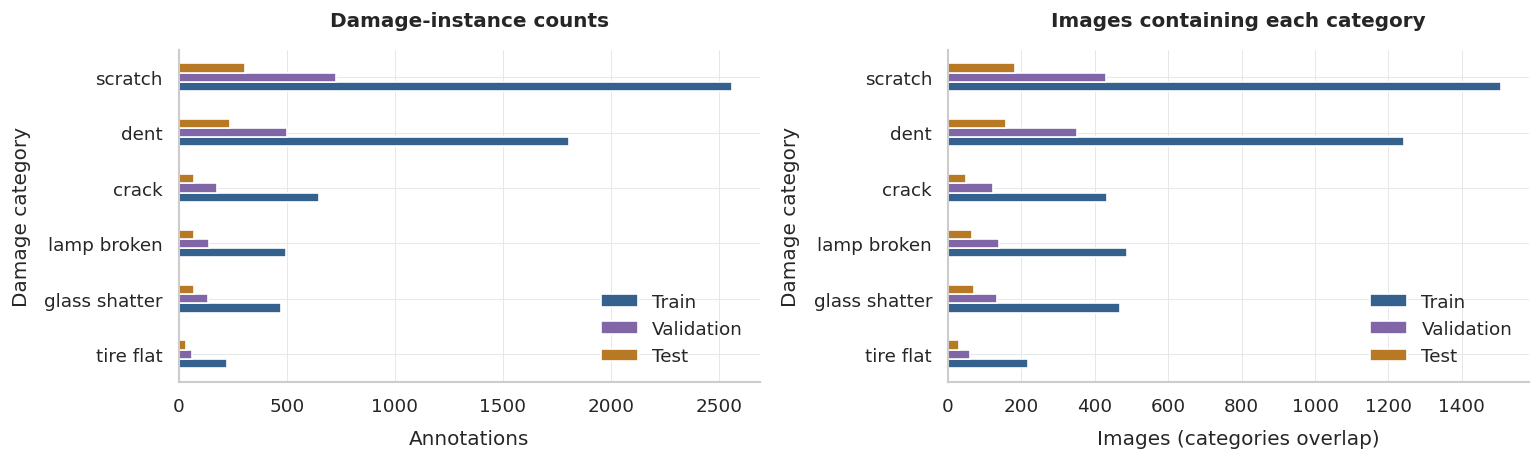

In [43]:
if RUN_CARDD_EDA:
    split_labels = {"train": "Train", "val": "Validation", "test": "Test"}
    split_palette = [
        SPLIT_COLORS["train"],
        SPLIT_COLORS["validation"],
        SPLIT_COLORS["test"],
    ]

    # Most common class at the top of every chart.
    class_order = (
        per_class.groupby("damage_class")["instances"]
        .sum()
        .sort_values(ascending=True)
        .index
    )
    instance_table = per_class.pivot(
        index="damage_class", columns="split", values="instances"
    )
    instance_table = instance_table.reindex(index=class_order, columns=list(split_labels))
    image_table = per_class.pivot(
        index="damage_class", columns="split", values="images_with_class"
    )
    image_table = image_table.reindex(index=class_order, columns=list(split_labels))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    panels = [
        (instance_table, "Damage instances per class", "Damage instances (n)"),
        (
            image_table,
            "Images containing each class",
            "Images (n); one image can count for several classes",
        ),
    ]
    # Stacked bars: total length is the class size, segments show where those examples live.
    for axis, (table, title, xlabel) in zip(axes, panels, strict=True):
        table.rename(columns=split_labels).plot.barh(
            stacked=True, ax=axis, color=split_palette, width=0.7, legend=False
        )
        axis.set_title(title)
        axis.set_xlabel(xlabel)
        axis.set_ylabel("")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.06))
    plt.tight_layout()
    plt.show()

### Is the data balanced?
If all six classes were equally common, each would be one sixth (16.7%) of the damage instances. The dashed line marks that level.

In [ ]:
if RUN_CARDD_EDA:
    class_totals = annotations["damage_class"].value_counts().sort_values()
    class_shares = 100 * class_totals / class_totals.sum()
    balanced_share = 100 / len(class_totals)
    imbalance_ratio = class_totals.max() / class_totals.min()

    # Red: under-represented relative to a balanced dataset.
    bar_colors = np.where(class_shares < balanced_share, RUST, BLUE)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(class_shares.index, class_shares.values, color=bar_colors)
    ax.axvline(
        balanced_share,
        color="black",
        linestyle="--",
        linewidth=1,
        label=f"perfectly balanced ({balanced_share:.1f}% each)",
    )
    for position, (share, count) in enumerate(zip(class_shares, class_totals, strict=True)):
        ax.text(
            share + 0.5,
            position,
            f"{share:.1f}%  ({count:,})",
            va="center",
            bbox={"facecolor": "white", "edgecolor": "none", "pad": 1},
        )

    ax.set_xlabel("Percent of all damage instances")
    ax.set_xlim(0, class_shares.max() * 1.25)
    ax.set_title(
        f"Classes are imbalanced: {class_totals.idxmax()} has {imbalance_ratio:.1f}x "
        f"as many instances as {class_totals.idxmin()}"
    )
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

The classes are far from balanced. Scratches are 41.1% of all instances and dents 29.1%, while the four remaining classes are each under the balanced 16.7%, down to 3.6% for flat tires: about 11 scratches for every flat tire. A detector trained naively will be pulled toward the common classes, so Stage 4 reports per-class average precision, not only overall mAP, and tries class-aware sampling or loss weighting for the rare classes.

### Is the imbalance the same in every split?
A fair test set should have the same class mix as training. The chart compares each class's share within each partition, and a chi-square test of independence checks whether the differences are larger than chance.

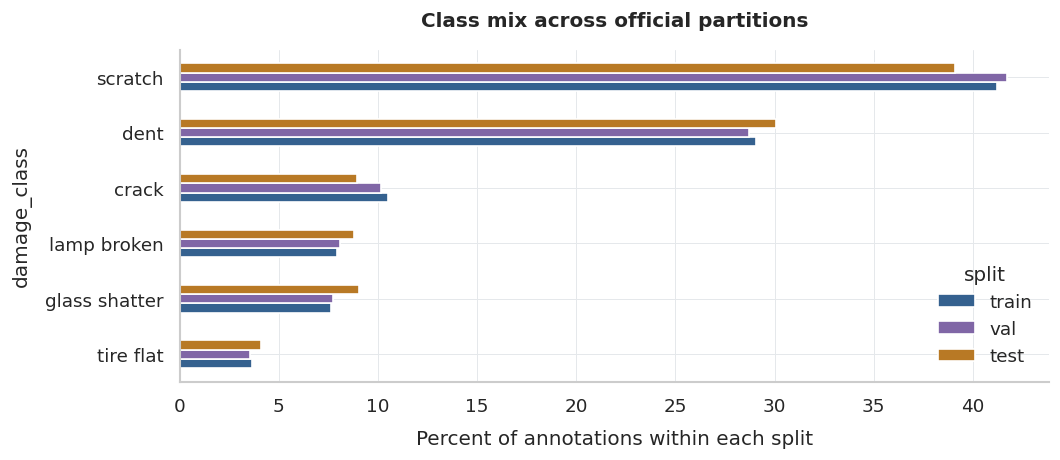

In [44]:
# Compare proportions because the three partitions have different sizes.
if RUN_CARDD_EDA:
    shares = per_class.pivot(
        index="damage_class", columns="split", values="share_of_split_instances"
    ).reindex(index=class_order, columns=list(split_labels))
    shares = (100 * shares.fillna(0)).rename(columns=split_labels)

    # barh draws the first column at the bottom of each group, so plot test-to-train
    # and reverse the legend: bars and legend then read Train, Validation, Test top to bottom.
    ax = shares[shares.columns[::-1]].plot.barh(
        figsize=(9, 4.5), color=split_palette[::-1], width=0.8
    )
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[::-1], labels[::-1], loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3
    )
    ax.set_xlabel("Percent of damage instances within the partition")
    ax.set_ylabel("")
    ax.set_title("Class mix is similar across the official partitions")
    plt.tight_layout()
    plt.show()

    # Chi-square test of independence: is class mix related to which split an instance is in?
    observed = pd.crosstab(annotations["damage_class"], annotations["split"])
    chi2, p_value, dof, expected = chi2_contingency(observed)
    # With 8,740 instances even tiny differences can be "significant"; Cramer's V measures size.
    cramers_v = np.sqrt(chi2 / (observed.values.sum() * (min(observed.shape) - 1)))
    print(f"Chi-square = {chi2:.2f}, df = {dof}, p = {p_value:.3f}")
    print(f"Cramer's V = {cramers_v:.3f} (0 = identical class mix in every split)")
    print(
        f"Smallest expected count = {expected.min():.1f} (test is valid when all are 5 or more)"
    )

The class mix is essentially identical across partitions: chi-square = 5.79 with 10 degrees of freedom, p = 0.83, and Cramér's V = 0.02. There is no evidence that the official split over- or under-represents any class, so test results will reflect the same imbalance the model trained on. The imbalance is a property of the dataset, not of the split.

Image-presence shares are multilabel; sums across classes need not equal 100%.
Images with zero annotations: 0


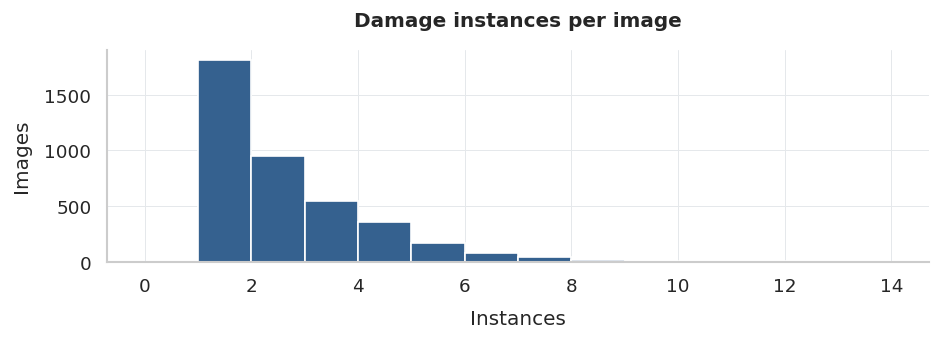

In [45]:
# Zero annotations would identify an unlabeled image, not certify an undamaged car.
if RUN_CARDD_EDA:
    if shares.isna().any().any():
        print(
            "Annotation shares are undefined for a zero-instance split; see NaN in table."
        )
    print("Image-presence shares are multilabel; sums across classes need not equal 100%.")
    instance_counts = (
        annotations.groupby(["split", "image_id"])
        .size()
        .rename("instances")
        .reset_index()
        .rename(columns={"image_id": "id"})
    )
    per_image = images.merge(
        instance_counts, on=["split", "id"], how="left", validate="one_to_one"
    ).fillna({"instances": 0})
    print("Images with zero annotations:", int((per_image["instances"] == 0).sum()))
    bins = range(0, int(per_image["instances"].max()) + 2)
    per_image["instances"].plot.hist(bins=bins, figsize=(8, 3))
    plt.title("Damage instances per image")
    plt.xlabel("Instances")
    plt.ylabel("Images")
    plt.tight_layout()
    plt.show()

In [46]:
def attach_image_geometry(images, annotations):
    """Match each box to its image and reject malformed coordinate records."""
    geometry = annotations.merge(
        images[["split", "id", "width", "height"]],
        left_on=["split", "image_id"],
        right_on=["split", "id"],
        validate="many_to_one",
        how="left",
        indicator=True,
    )
    if not geometry["_merge"].eq("both").all():
        raise ValueError("An annotation points to an image absent from its split.")

    # Validate each record before conversion; reshaping could hide a malformed box.
    for box in geometry["bbox"]:
        if not isinstance(box, (list, tuple)) or len(box) != 4:
            raise ValueError("Each COCO box must have four values: x, y, width, height.")
    boxes = np.asarray(geometry["bbox"].tolist(), dtype=float).reshape(-1, 4)
    if not np.isfinite(boxes).all():
        raise ValueError("Bounding-box coordinates must be finite numbers.")
    return geometry, boxes


if RUN_CARDD_EDA:
    geometry, boxes = attach_image_geometry(images, annotations)
    width = geometry["width"].to_numpy()
    height = geometry["height"].to_numpy()

In [47]:
# Allow the original one-pixel boundary tolerance; do not clip boxes.
if RUN_CARDD_EDA:
    x, y, box_width, box_height = boxes.T
    invalid = (
        (box_width <= 0)
        | (box_height <= 0)
        | (x < 0)
        | (y < 0)
        | (x + box_width > width + 1)
        | (y + box_height > height + 1)
    )
    print("Invalid or out-of-frame boxes:", int(invalid.sum()))
    assert (images["width"] > 0).all() and (images["height"] > 0).all()
    print(
        "Excluded from box-geometry summaries:",
        int(invalid.sum()),
        "of",
        len(boxes),
        "annotations; no clipping applied.",
    )
    geometry = geometry.loc[~invalid].copy()
    boxes, width, height = boxes[~invalid], width[~invalid], height[~invalid]
    geometry["box_fraction"] = boxes[:, 2] * boxes[:, 3] / (width * height)
    geometry["box_aspect"] = np.divide(
        boxes[:, 2], boxes[:, 3], out=np.full(len(boxes), np.nan), where=boxes[:, 3] > 0
    )
    print(
        "Duplicate filenames within splits:",
        int(images.duplicated(["split", "file_name"]).sum()),
    )
    print(
        "Missing or empty segmentations:",
        sum(mask is None or mask == [] for mask in geometry["segmentation"]),
    )
    missing_files = sum(
        not (CARDD_IMAGE_DIRS[row.split] / row.file_name).is_file()
        for row in images.itertuples()
    )
    print("Missing pixel references:", missing_files)

Invalid or out-of-frame boxes: 0
Excluded from box-geometry summaries: 0 of 8740 annotations; no clipping applied.
Duplicate filenames within splits: 0
Missing or empty segmentations: 0
Missing pixel references: 0


box_fraction                                                \
                     count   mean    std        min    25%    50%    75%   
damage_class                                                               
crack                898.0  0.035  0.079  1.748e-04  0.004  0.010  0.030   
dent                2543.0  0.135  0.148  2.025e-04  0.034  0.082  0.184   
glass shatter        681.0  0.648  0.274  1.485e-02  0.454  0.678  0.885   
lamp broken          704.0  0.233  0.188  2.513e-03  0.092  0.181  0.337   
scratch             3595.0  0.114  0.146  8.488e-04  0.020  0.056  0.147   
tire flat            319.0  0.358  0.191  9.369e-03  0.206  0.347  0.492   

                     box_aspect                                            \
                 max      count   mean    std    min    25%    50%    75%   
damage_class                                                                
crack          0.873      898.0  1.501  1.659  0.048  0.512  0.977  1.904   
dent           1.000     2543.0  1.417  1.074  0.162  0.822  1.158  1.661   
glass shatter  1.000      681.0  1.737  0.651  0.500  1.383  1.564  1.943   
lamp broken    1.000      704.0  1.689  0.796  0.267  1.128  1.620  2.154   
scratch        1.000     3595.0  2.056  1.976  0.068  0.887  1.474  2.504   
tire flat      0.978      319.0  0.998  0.243  0.267  0.812  1.058  1.148   

                       
                  max  
damage_class           
crack          16.576  
dent           14.375  
glass shatter   6.202  
lamp broken     8.145  
scratch        25.659  
tire flat       1.763

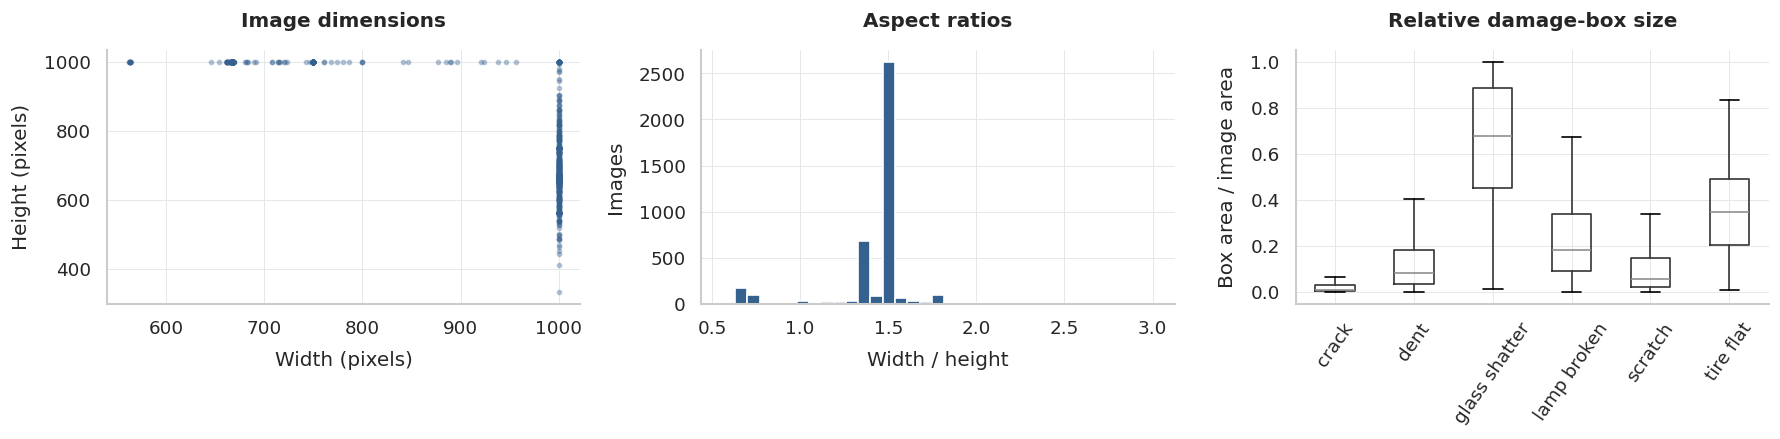

width                                                          height  \
        count     mean     std    min     25%     50%     75%     max   count   
split                                                                           
test    374.0  977.751  82.621  563.0  1000.0  1000.0  1000.0  1000.0   374.0   
train  2816.0  978.998  77.449  562.0  1000.0  1000.0  1000.0  1000.0  2816.0   
val     810.0  974.936  85.346  562.0  1000.0  1000.0  1000.0  1000.0   810.0   

                                                             
          mean      std    min    25%    50%    75%     max  
split                                                        
test   702.912   95.961  490.0  667.0  667.0  704.0  1000.0  
train  705.301   97.174  333.0  667.0  667.0  750.0  1000.0  
val    710.710  100.983  484.0  667.0  667.0  750.0  1000.0

In [48]:
# Relative box area describes localization scale, not damage severity.
if RUN_CARDD_EDA:
    display(geometry.groupby("damage_class")[["box_fraction", "box_aspect"]].describe())
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].scatter(images["width"], images["height"], s=6, alpha=0.3)
    axes[0].set(xlabel="Width (pixels)", ylabel="Height (pixels)", title="Image dimensions")
    axes[1].hist(images["width"] / images["height"], bins=35)
    axes[1].set(xlabel="Width / height", ylabel="Images", title="Aspect ratios")
    if len(geometry):
        geometry.boxplot(
            column="box_fraction", by="damage_class", ax=axes[2], showfliers=False, rot=55
        )
    else:
        axes[2].text(
            0.5,
            0.5,
            "No annotations in these files",
            ha="center",
            transform=axes[2].transAxes,
        )
    axes[2].set(xlabel="", ylabel="Box area / image area", title="Relative damage-box size")
    fig.suptitle("")
    plt.tight_layout()
    plt.show()
    display(images.groupby("split")[["width", "height"]].describe())

In [49]:
# Different filenames cannot establish different vehicles or different image content.
if RUN_CARDD_EDA:
    filename_sets = {
        split: set(frame["file_name"].astype(str))
        for split, frame in images.groupby("split")
    }
    pairs = [("train", "val"), ("train", "test"), ("val", "test")]
    shared_names = {f"{a}_{b}": len(filename_sets[a] & filename_sets[b]) for a, b in pairs}
    print("Cross-split shared filenames:", shared_names)
    print(
        "Filenames and annotation IDs do not establish vehicle-disjointness or absence of perceptual duplicates."
    )

Cross-split shared filenames: {'train_val': 0, 'train_test': 0, 'val_test': 0}
Filenames and annotation IDs do not establish vehicle-disjointness or absence of perceptual duplicates.


In [50]:
def draw_damage_annotations(axis, image_path, image_annotations, categories):
    """Draw native boxes and polygon masks; report masks that need an RLE decoder."""
    with Image.open(image_path) as image:
        axis.imshow(image.convert("RGB"))

    rle_masks = 0
    for annotation in image_annotations.itertuples():
        x, y, box_width, box_height = annotation.bbox
        axis.add_patch(
            Rectangle(
                (x, y),
                box_width,
                box_height,
                fill=False,
                edgecolor="#F7B32B",
                linewidth=1.4,
            )
        )
        axis.text(
            x,
            y,
            categories[int(annotation.category_id)],
            color="black",
            fontsize=8,
            bbox={"facecolor": "#F7B32B", "alpha": 0.85, "pad": 1},
        )
        if isinstance(annotation.segmentation, list):
            for polygon in annotation.segmentation:
                if len(polygon) >= 6:
                    points = np.asarray(polygon).reshape(-1, 2)
                    axis.add_patch(Polygon(points, facecolor="#53A7D8", alpha=0.25))
        else:
            rle_masks += 1
    return rle_masks

### Inspect fixed examples with their native labels

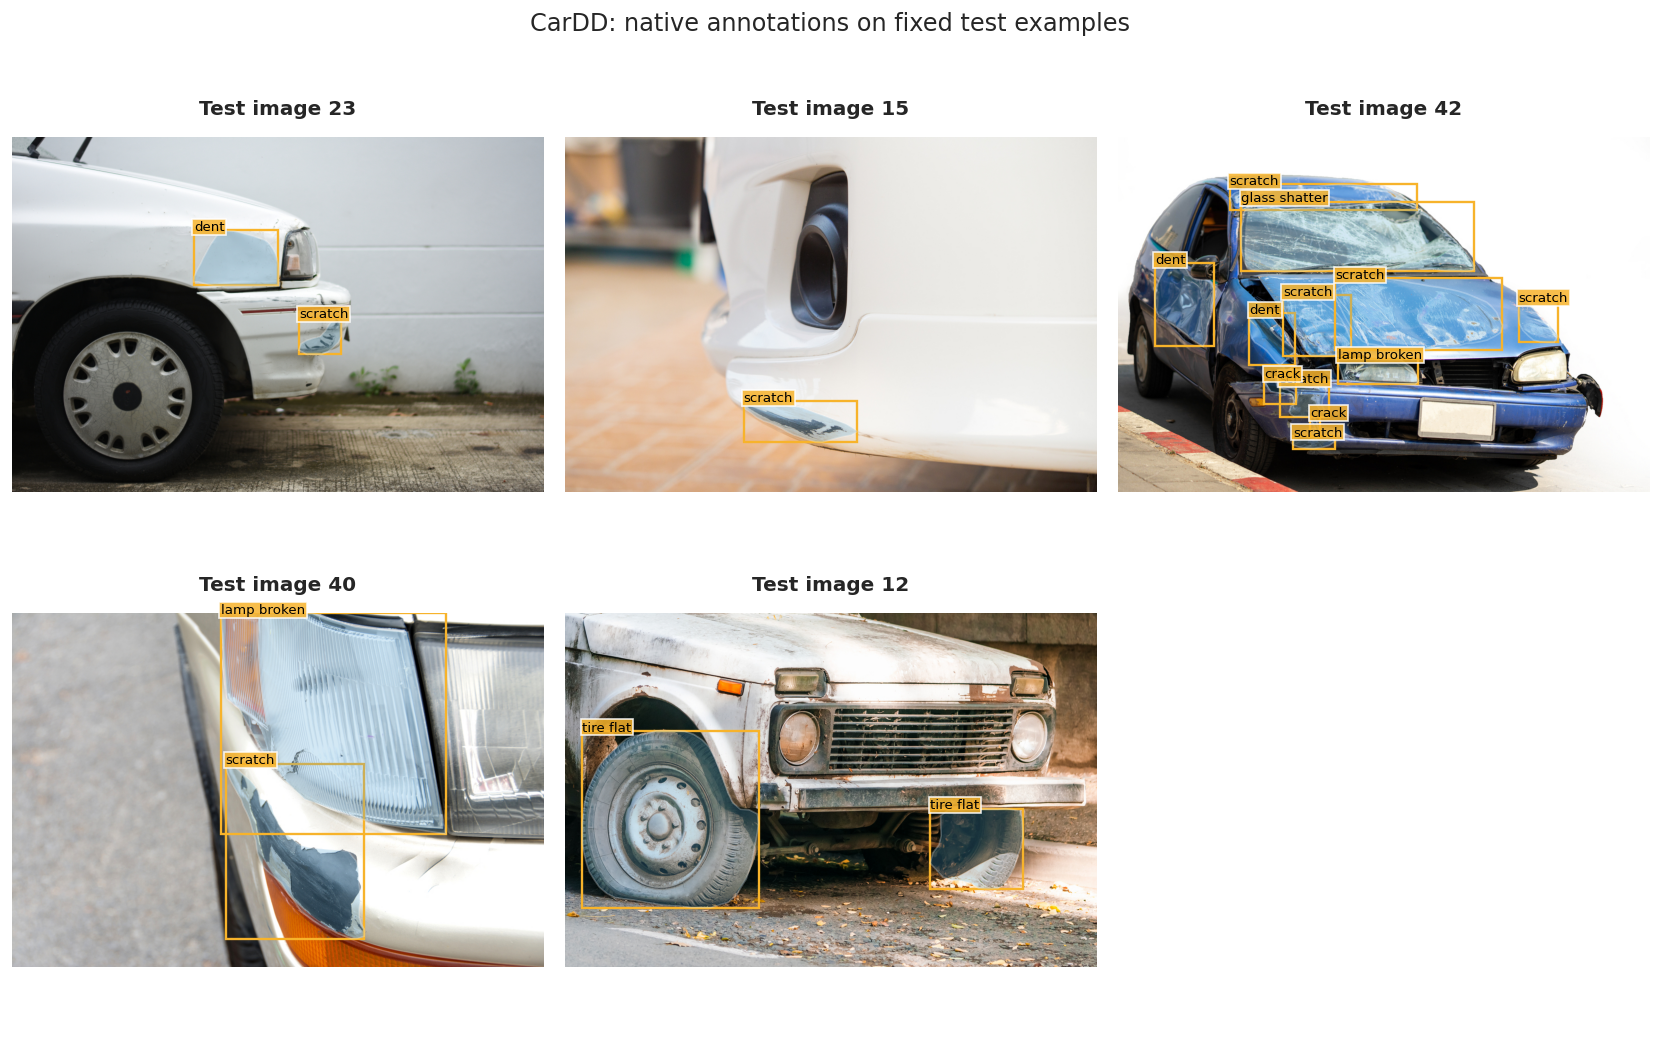

Missing pixel files: []
Non-polygon masks not rendered: 0


In [51]:
if RUN_CARDD_EDA:
    # Keep the original deterministic selection; these are examples, not model tests.
    test_annotations = geometry.loc[geometry["split"].eq("test")].copy()
    chosen_images = []
    for category_id in sorted(categories):
        matching = test_annotations.loc[
            test_annotations["category_id"].eq(category_id), "image_id"
        ]
        image_ids = sorted(matching.unique())
        if image_ids and image_ids[0] not in chosen_images:
            chosen_images.append(image_ids[0])

    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    missing_pixels = []
    rle_masks = 0
    for axis in axes.ravel():
        axis.axis("off")
    # Up to six examples; unused panels stay blank, so the lengths can differ.
    for axis, image_id in zip(axes.ravel(), chosen_images[:6], strict=False):
        image_row = images.loc[
            (images["split"] == "test") & (images["id"] == image_id)
        ].iloc[0]
        image_path = CARDD_IMAGE_DIRS["test"] / image_row["file_name"]
        if not image_path.is_file():
            missing_pixels.append(str(image_path))
            axis.set_title("Pixel file unavailable")
            continue
        image_annotations = test_annotations.loc[test_annotations["image_id"].eq(image_id)]
        rle_masks += draw_damage_annotations(
            axis, image_path, image_annotations, categories
        )
        axis.set_title(f"Test image {image_id}")

    fig.suptitle("CarDD: native annotations on fixed test examples")
    plt.tight_layout()
    plt.show()
    print("Missing pixel files:", missing_pixels)
    print("Non-polygon masks not rendered:", rle_masks)

### CarDD takeaways
- **4,000 images, 8,740 annotated instances** (2,816 / 810 / 374 images; 6,211 / 1,744 / 785 instances). No annotation-negative images appear in this release; there is no independently labeled clean-car control group. Annotation presence is not an independent review of every photograph.
- **Class imbalance:** scratches account for about 41% of training instances and dents for 29%; tire flat has 225 training instances (3.6%). Report per-class AP alongside overall mAP.
- **Box size varies by class:** median boxes cover about 1% of the image for cracks, 6–8% for scratches and dents, 35% for flat tires, and 68% for shattered glass. Small crack boxes may be harder to localize; this EDA does not establish which class a model finds hardest.
- The saved checks found no invalid boxes, empty segmentations, missing pixel references, or filenames shared across splits. Class shares are similar across the official partitions. These checks do not establish annotation correctness or vehicle independence.
- The optional byte-duplicate scan remains off. It would detect exact file equality, not crops, re-encoding, or different views of the same vehicle.

In [52]:
# Byte hashes detect exact files, not crops, re-encoding, or repeated vehicles.
if RUN_CARDD_EDA and HASH_CARDD_PIXELS:
    pixel_rows = []
    for row in images.itertuples():
        image_path = CARDD_IMAGE_DIRS[row.split] / row.file_name
        digest = file_sha256(image_path) if image_path.is_file() else None
        pixel_rows.append({"split": row.split, "image_id": row.id, "sha256": digest})

    hashes = pd.DataFrame(pixel_rows)
    known_hashes = hashes.dropna(subset=["sha256"])
    splits_per_hash = known_hashes.groupby("sha256")["split"].nunique()
    print("Missing pixel files:", hashes["sha256"].isna().sum())
    print("Repeated byte hashes:", known_hashes["sha256"].duplicated().sum())
    print("Hashes in multiple partitions:", (splits_per_hash > 1).sum())
else:
    print("Byte-duplicate audit not run; pixel and vehicle independence remain unverified.")

Byte-duplicate audit not run; pixel and vehicle independence remain unverified.


## Next steps (Stage 4)
- Evaluate lowercase/trim normalization as a documented preprocessing revision, fitting category vocabularies on training data only and comparing on the same split. Preserve historical model results; the recorded-MMR test MAE is \$1,083.
- Train the CarDD baseline detector on the official split and report per-class AP.
- Build a labeled clean-car control set for the damage false-alarm test.

## Additional references
- CarDD: https://cardd-ustc.github.io/ ; Wang, Li & Wu (2023), *IEEE T-ITS*.
- Course guidelines: DSBA 6165 project description.